# IMPORT LIBRARY & REPRODUCIBILITY

In [123]:
import os, random
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time


print('set seed..')
time.sleep(2)
seed = 42

os.environ['PYTHONHASHSEED'] =str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = "1"
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print('set seed DONE')

set seed..
set seed DONE


# LOAD DATA

In [124]:
data = pd.read_excel('/kaggle/input/data-gwpr/hasil_gwpr_gaussian_false (1).xlsx')
data

,Unnamed: 0,Province,Year,Month,Production,Importation,Demand,Supply,Price,Population,...,Demand_significant,Supply_pvalue,Supply_significant,Population_pvalue,Population_significant,Religious Holiday_pvalue,Religious Holiday_significant,Actual,Predicted,Residual
0,0,Aceh,2013,1,0.0,0.00,3262.0,0.00,12500.0,4811100,...,0,0.984258,0,0.018166,1,0.246776,0,12500.0,13326.308616,-826.308616
1,1,Aceh,2013,1,0.0,16.02,3399.0,16.02,12000.0,4906800,...,0,0.984258,0,0.018166,1,0.246776,0,12000.0,13371.300270,-1371.300270
2,2,Aceh,2013,1,0.0,0.00,2902.0,0.00,11000.0,5020000,...,0,0.984258,0,0.018166,1,0.246776,0,11000.0,13295.987232,-2295.987232
3,3,Aceh,2013,1,0.0,0.00,2529.0,0.00,13000.0,5096200,...,0,0.984258,0,0.018166,1,0.246776,0,13000.0,13281.710313,-281.710313
4,4,Aceh,2013,1,0.0,0.00,4706.0,0.00,14500.0,5189500,...,0,0.984258,0,0.018166,1,0.246776,0,14500.0,13299.282435,1200.717565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,4075,Yogyakarta,2017,11,0.0,0.00,2663.0,0.00,13239.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,13239.0,12200.070293,1038.929707
4076,4076,Yogyakarta,2017,12,0.0,0.00,4297.0,0.00,12424.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12424.0,12544.187168,-120.187168
4077,4077,Yogyakarta,2017,12,0.0,0.00,2670.0,0.00,12500.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12500.0,12566.209965,-66.209965
4078,4078,Yogyakarta,2017,12,0.0,0.00,3180.0,0.00,12500.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12500.0,12559.306691,-59.306691


In [125]:
print('Provinsi tiap tahun : ' ,data.groupby('Year')['Province'].nunique())


Provinsi tiap tahun :  Year
2013    4
2014    4
2015    5
2016    4
2017    4
2018    4
2019    4
2020    5
2021    4
2022    4
Name: Province, dtype: int64


In [126]:
data['Province'].unique()

array(['Aceh', 'Bali', 'Bangka-Belitung', 'Banten', 'Bengkulu',
       'Gorontalo', 'Jakarta Raya', 'Jambi', 'Jawa Barat', 'Jawa Tengah',
       'Jawa Timur', 'Kalimantan Barat', 'Kalimantan Selatan',
       'Kalimantan Tengah', 'Kalimantan Timur', 'Kalimantan Utara',
       'Kepulauan Riau', 'Lampung', 'Maluku', 'Maluku Utara',
       'Nusa Tenggara Barat', 'Nusa Tenggara Timur', 'Papua',
       'Papua Barat', 'Riau', 'Sulawesi Barat', 'Sulawesi Selatan',
       'Sulawesi Tengah', 'Sulawesi Tenggara', 'Sulawesi Utara',
       'Sumatera Barat', 'Sumatera Selatan', 'Sumatera Utara',
       'Yogyakarta'], dtype=object)

In [127]:
data['Province'] = data['Province'].replace({
    'Bangka Belitung': 'Bangka-Belitung',
    'Jakarta': 'Jakarta Raya'})

data

,Unnamed: 0,Province,Year,Month,Production,Importation,Demand,Supply,Price,Population,...,Demand_significant,Supply_pvalue,Supply_significant,Population_pvalue,Population_significant,Religious Holiday_pvalue,Religious Holiday_significant,Actual,Predicted,Residual
0,0,Aceh,2013,1,0.0,0.00,3262.0,0.00,12500.0,4811100,...,0,0.984258,0,0.018166,1,0.246776,0,12500.0,13326.308616,-826.308616
1,1,Aceh,2013,1,0.0,16.02,3399.0,16.02,12000.0,4906800,...,0,0.984258,0,0.018166,1,0.246776,0,12000.0,13371.300270,-1371.300270
2,2,Aceh,2013,1,0.0,0.00,2902.0,0.00,11000.0,5020000,...,0,0.984258,0,0.018166,1,0.246776,0,11000.0,13295.987232,-2295.987232
3,3,Aceh,2013,1,0.0,0.00,2529.0,0.00,13000.0,5096200,...,0,0.984258,0,0.018166,1,0.246776,0,13000.0,13281.710313,-281.710313
4,4,Aceh,2013,1,0.0,0.00,4706.0,0.00,14500.0,5189500,...,0,0.984258,0,0.018166,1,0.246776,0,14500.0,13299.282435,1200.717565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,4075,Yogyakarta,2017,11,0.0,0.00,2663.0,0.00,13239.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,13239.0,12200.070293,1038.929707
4076,4076,Yogyakarta,2017,12,0.0,0.00,4297.0,0.00,12424.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12424.0,12544.187168,-120.187168
4077,4077,Yogyakarta,2017,12,0.0,0.00,2670.0,0.00,12500.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12500.0,12566.209965,-66.209965
4078,4078,Yogyakarta,2017,12,0.0,0.00,3180.0,0.00,12500.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12500.0,12559.306691,-59.306691


# EDA

In [128]:
datas = data.copy()

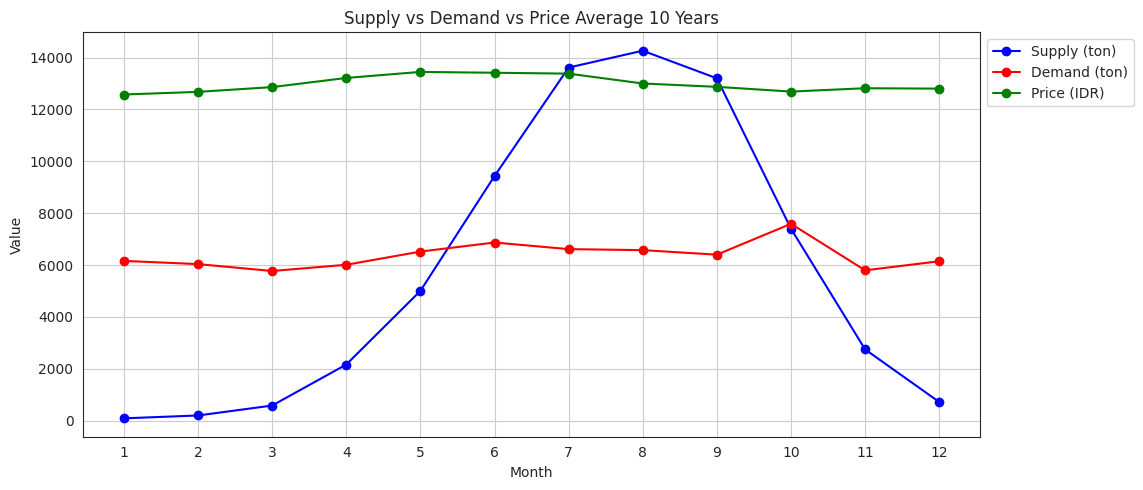

In [129]:
avg_supply_per_month = datas.groupby("Month")["Supply"].mean()
avg_demand_per_month = datas.groupby("Month")["Demand"].mean()
avg_price_per_month = datas.groupby("Month")["Price"].mean()
# Plot
plt.figure(figsize=(10, 5))
plt.plot(avg_supply_per_month.index, avg_supply_per_month.values, marker='o', linestyle='-', color='b', label='Supply (ton)')
plt.plot(avg_demand_per_month.index, avg_demand_per_month.values, marker='o', linestyle='-', color='r', label='Demand (ton)')
plt.plot(avg_price_per_month.index, avg_price_per_month.values, marker='o', linestyle='-', color='g', label='Price (IDR)')
plt.title("Supply vs Demand vs Price Average 10 Years")
plt.xlabel("Month")
plt.ylabel("Value")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.savefig('Supply vs Demand vs Price Average 10 Years.jpg', dpi=800)
plt.show()


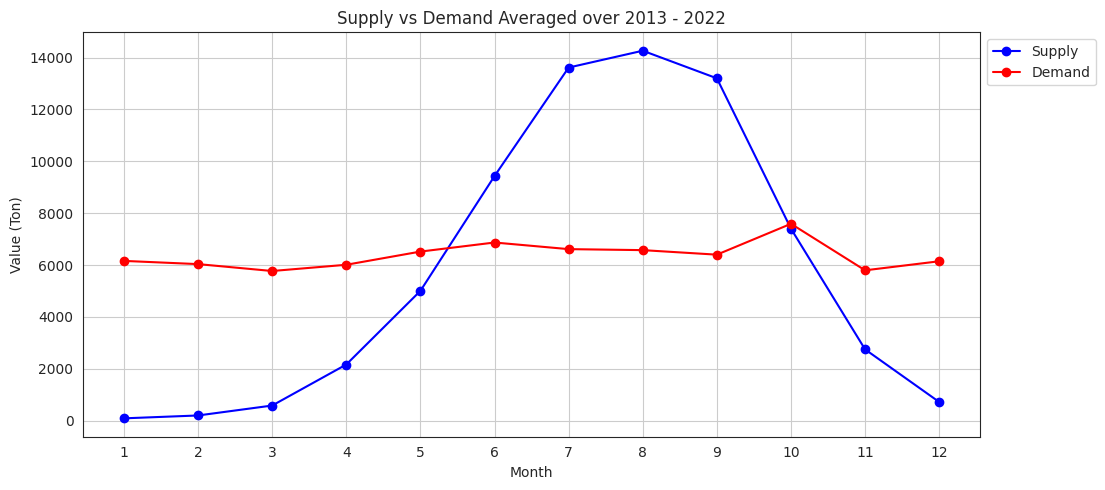

------------------------------------------------------------


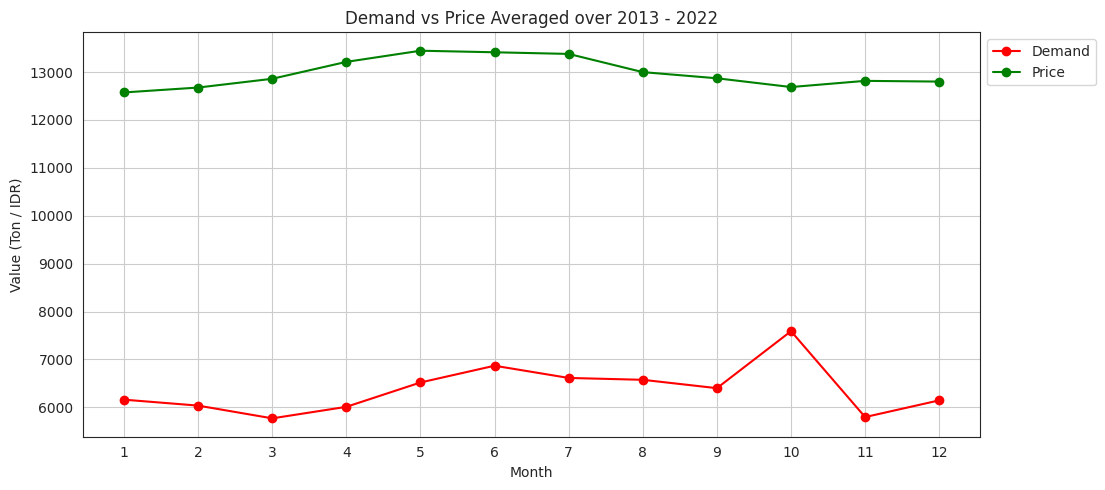

--


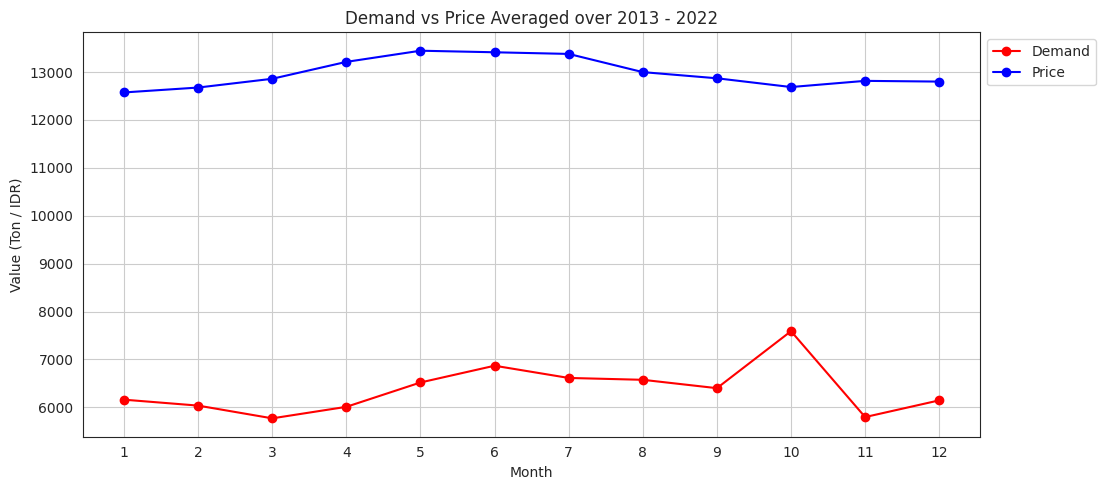

In [130]:
avg_supply_per_month = datas.groupby("Month")["Supply"].mean()
avg_demand_per_month = datas.groupby("Month")["Demand"].mean()
avg_price_per_month = datas.groupby("Month")["Price"].mean()
# Plot
plt.figure(figsize=(10, 5))
plt.plot(avg_supply_per_month.index, avg_supply_per_month.values, marker='o', linestyle='-', color='b', label='Supply')
plt.plot(avg_demand_per_month.index, avg_demand_per_month.values, marker='o', linestyle='-', color='r', label='Demand')
# plt.plot(avg_price_per_month.index, avg_price_per_month.values, marker='o', linestyle='-', color='g', label='Price (IDR)')
plt.title("Supply vs Demand Averaged over 2013 - 2022")
plt.xlabel("Month")
plt.ylabel("Value (Ton)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.savefig('Supply vs Demand Averaged over 2013 - 2022.jpg', dpi=800)
plt.show()


#---
print('--'*30)
plt.figure(figsize=(10, 5))
# plt.plot(avg_supply_per_month.index, avg_supply_per_month.values, marker='o', linestyle='-', color='b', label='Supply')
plt.plot(avg_demand_per_month.index, avg_demand_per_month.values, marker='o', linestyle='-', color='r', label='Demand')
plt.plot(avg_price_per_month.index, avg_price_per_month.values, marker='o', linestyle='-', color='g', label='Price')
plt.title("Demand vs Price Averaged over 2013 - 2022")
plt.xlabel("Month")
plt.ylabel("Value (Ton / IDR)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.savefig('Demand vs Price Averaged over 2013 - 2022.jpg', dpi=800)
plt.show()

print('--')
plt.figure(figsize=(10, 5))
# plt.plot(avg_supply_per_month.index, avg_supply_per_month.values, marker='o', linestyle='-', color='b', label='Supply')
plt.plot(avg_demand_per_month.index, avg_demand_per_month.values, marker='o', linestyle='-', color='r', label='Demand')
plt.plot(avg_price_per_month.index, avg_price_per_month.values, marker='o', linestyle='-', color='b', label='Price')
plt.title("Demand vs Price Averaged over 2013 - 2022")
plt.xlabel("Month")
plt.ylabel("Value (Ton / IDR)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.savefig('Demand vs Price Averaged over 2013 - 2022 (blue red).jpg', dpi=800)
plt.show()


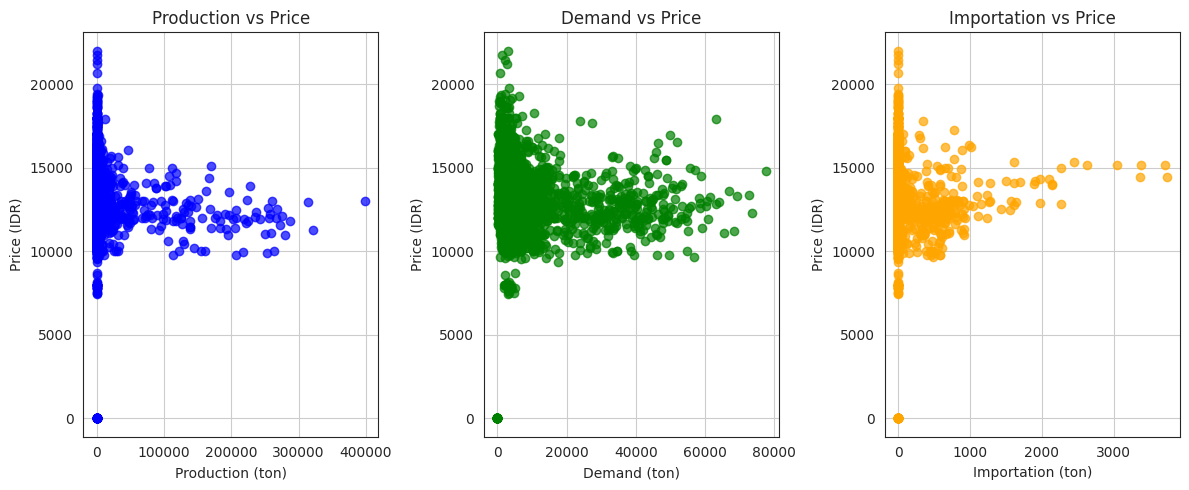

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Production (ton) vs Price (IDR)
plt.subplot(131)
plt.scatter(datas['Production'], datas['Price'], alpha=0.7, color='blue')
plt.xlabel("Production (ton)")
plt.ylabel("Price (IDR)")
plt.title("Production vs Price")
plt.grid(True)

# 2. Demand (ton) vs Price (IDR)
plt.subplot(132)
plt.scatter(datas['Demand'], datas['Price'], alpha=0.7, color='green')
plt.xlabel("Demand (ton)")
plt.ylabel("Price (IDR)")
plt.title("Demand vs Price")
plt.grid(True)

# 3. Importation (ton) vs Price (IDR)
plt.subplot(133)
plt.scatter(datas['Importation'], datas['Price'], alpha=0.7, color='orange')
plt.xlabel("Importation (ton)")
plt.ylabel("Price (IDR)")
plt.title("Importation vs Price")
plt.grid(True)

plt.tight_layout()
plt.savefig('scatter_plot_Prod_Impor_Demand_Price.jpg', dpi=800)
plt.show()


# DATA CLEANING

## 1) REMOVE IRRELEVANT FEATURES

In [132]:
data.columns

Index(['Unnamed: 0', 'Province', 'Year', 'Month', 'Production', 'Importation',
       'Demand', 'Supply', 'Price', 'Population', 'Religious Holiday',
       'residual', 'geometry', 'centroid', 'lon', 'lat', 'intercept',
       'Production_coef', 'Importation_coef', 'Demand_coef', 'Supply_coef',
       'Population_coef', 'Religious Holiday_coef', 'Production_pvalue',
       'Production_significant', 'Importation_pvalue',
       'Importation_significant', 'Demand_pvalue', 'Demand_significant',
       'Supply_pvalue', 'Supply_significant', 'Population_pvalue',
       'Population_significant', 'Religious Holiday_pvalue',
       'Religious Holiday_significant', 'Actual', 'Predicted', 'Residual'],
      dtype='object')

In [133]:
# # kolom_drop1 = ['Unnamed: 0', 'Unnamed: 0.1', 'No', 'geometry', 'centroid', 'lon', 'lat', 'Actual']
kolom_drop1 = ['Unnamed: 0', 'geometry', 'centroid', 'lon', 'lat', 'residual','Actual']
# kolom_drop1 = ['Unnamed: 0', 'Actual']
kolom_drop1

['Unnamed: 0', 'geometry', 'centroid', 'lon', 'lat', 'residual', 'Actual']

In [134]:
kolom_drop2 = data.columns[data.columns.str.endswith('significant')]
kolom_drop2 = kolom_drop2.tolist()
kolom_drop2

['Production_significant',
 'Importation_significant',
 'Demand_significant',
 'Supply_significant',
 'Population_significant',
 'Religious Holiday_significant']

In [135]:
kolom_drop = kolom_drop1 + kolom_drop2
kolom_drop

# kolom_drop = ['No']

['Unnamed: 0',
 'geometry',
 'centroid',
 'lon',
 'lat',
 'residual',
 'Actual',
 'Production_significant',
 'Importation_significant',
 'Demand_significant',
 'Supply_significant',
 'Population_significant',
 'Religious Holiday_significant']

In [136]:
data = data.drop(kolom_drop, axis=1)
data

,Province,Year,Month,Production,Importation,Demand,Supply,Price,Population,Religious Holiday,...,Population_coef,Religious Holiday_coef,Production_pvalue,Importation_pvalue,Demand_pvalue,Supply_pvalue,Population_pvalue,Religious Holiday_pvalue,Predicted,Residual
0,Aceh,2013,1,0.0,0.00,3262.0,0.00,12500.0,4811100,0,...,-0.646329,0.061372,0.984109,0.947903,0.697051,0.984258,0.018166,0.246776,13326.308616,-826.308616
1,Aceh,2013,1,0.0,16.02,3399.0,16.02,12000.0,4906800,0,...,-0.646329,0.061372,0.984109,0.947903,0.697051,0.984258,0.018166,0.246776,13371.300270,-1371.300270
2,Aceh,2013,1,0.0,0.00,2902.0,0.00,11000.0,5020000,0,...,-0.646329,0.061372,0.984109,0.947903,0.697051,0.984258,0.018166,0.246776,13295.987232,-2295.987232
3,Aceh,2013,1,0.0,0.00,2529.0,0.00,13000.0,5096200,0,...,-0.646329,0.061372,0.984109,0.947903,0.697051,0.984258,0.018166,0.246776,13281.710313,-281.710313
4,Aceh,2013,1,0.0,0.00,4706.0,0.00,14500.0,5189500,0,...,-0.646329,0.061372,0.984109,0.947903,0.697051,0.984258,0.018166,0.246776,13299.282435,1200.717565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,Yogyakarta,2017,11,0.0,0.00,2663.0,0.00,13239.0,3762200,0,...,0.201285,0.067044,0.014209,0.521890,0.374239,0.025180,0.013923,0.270268,12200.070293,1038.929707
4076,Yogyakarta,2017,12,0.0,0.00,4297.0,0.00,12424.0,3762200,1,...,0.201285,0.067044,0.014209,0.521890,0.374239,0.025180,0.013923,0.270268,12544.187168,-120.187168
4077,Yogyakarta,2017,12,0.0,0.00,2670.0,0.00,12500.0,3762200,1,...,0.201285,0.067044,0.014209,0.521890,0.374239,0.025180,0.013923,0.270268,12566.209965,-66.209965
4078,Yogyakarta,2017,12,0.0,0.00,3180.0,0.00,12500.0,3762200,1,...,0.201285,0.067044,0.014209,0.521890,0.374239,0.025180,0.013923,0.270268,12559.306691,-59.306691


In [137]:
data.columns.tolist()

['Province',
 'Year',
 'Month',
 'Production',
 'Importation',
 'Demand',
 'Supply',
 'Price',
 'Population',
 'Religious Holiday',
 'intercept',
 'Production_coef',
 'Importation_coef',
 'Demand_coef',
 'Supply_coef',
 'Population_coef',
 'Religious Holiday_coef',
 'Production_pvalue',
 'Importation_pvalue',
 'Demand_pvalue',
 'Supply_pvalue',
 'Population_pvalue',
 'Religious Holiday_pvalue',
 'Predicted',
 'Residual']

## 2) Nan Check

In [138]:
data.isna().sum()

Province                    0
Year                        0
Month                       0
Production                  0
Importation                 0
Demand                      0
Supply                      0
Price                       0
Population                  0
Religious Holiday           0
intercept                   0
Production_coef             0
Importation_coef            0
Demand_coef                 0
Supply_coef                 0
Population_coef             0
Religious Holiday_coef      0
Production_pvalue           0
Importation_pvalue          0
Demand_pvalue               0
Supply_pvalue               0
Population_pvalue           0
Religious Holiday_pvalue    0
Predicted                   0
Residual                    0
dtype: int64

In [139]:
# from sklearn.impute import KNNImputer

# cols_to_impute = ['Production', 'Demand', 'Supply', 'Price']
# # cols_to_impute


# imputer = KNNImputer(n_neighbors = 3)
# data[cols_to_impute] = imputer.fit_transform(data[cols_to_impute])
# data

# PROCESSING

## 1) Set Multi Index - PANEL 

In [140]:
data = data.set_index(['Province', 'Year', 'Month']).sort_index()
data 

Production  Importation  Demand  Supply    Price  \
Province   Year Month                                                     
Aceh       2013 1             0.0         0.00  3262.0    0.00  12500.0   
                1             0.0        16.02  3399.0   16.02  12000.0   
                1             0.0         0.00  2902.0    0.00  11000.0   
                1             0.0         0.00  2529.0    0.00  13000.0   
                1             0.0         0.00  4706.0    0.00  14500.0   
...                           ...          ...     ...     ...      ...   
Yogyakarta 2017 11            0.0         0.00  2663.0    0.00  13239.0   
                12            0.0         0.00  4297.0    0.00  12424.0   
                12            0.0         0.00  2670.0    0.00  12500.0   
                12            0.0         0.00  3180.0    0.00  12500.0   
                12            0.0         0.00  3724.0    0.00  13386.0   

                       Population  Religious Holiday  intercept  \
Province   Year Month                                             
Aceh       2013 1         4811100                  0   0.103006   
                1         4906800                  0   0.103006   
                1         5020000                  0   0.103006   
                1         5096200                  0   0.103006   
                1         5189500                  0   0.103006   
...                           ...                ...        ...   
Yogyakarta 2017 11        3762200                  0  -0.291752   
                12        3762200                  1  -0.291752   
                12        3762200                  1  -0.291752   
                12        3762200                  1  -0.291752   
                12        3762200                  1  -0.291752   

                       Production_coef  Importation_coef  ...  \
Province   Year Month                                     ...   
Aceh       2013 1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
...                                ...               ...  ...   
Yogyakarta 2017 11            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   

                       Population_coef  Religious Holiday_coef  \
Province   Year Month                                            
Aceh       2013 1            -0.646329                0.061372   
                1            -0.646329                0.061372   
                1            -0.646329                0.061372   
                1            -0.646329                0.061372   
                1            -0.646329                0.061372   
...                                ...                     ...   
Yogyakarta 2017 11            0.201285                0.067044   
                12            0.201285                0.067044   
                12            0.201285                0.067044   
                12            0.201285                0.067044   
                12            0.201285                0.067044   

                       Production_pvalue  Importation_pvalue  Demand_pvalue  \
Province   Year Month                                                         
Aceh       2013 1               0.984109            0.947903       0.697051   
                1               0.984109            0.947903       0.697051   
                1               0.984109            0.947903       0.697051   
                1               0.984109            0.947903       0.697051

In [141]:
data.columns

Index(['Production', 'Importation', 'Demand', 'Supply', 'Price', 'Population',
       'Religious Holiday', 'intercept', 'Production_coef', 'Importation_coef',
       'Demand_coef', 'Supply_coef', 'Population_coef',
       'Religious Holiday_coef', 'Production_pvalue', 'Importation_pvalue',
       'Demand_pvalue', 'Supply_pvalue', 'Population_pvalue',
       'Religious Holiday_pvalue', 'Predicted', 'Residual'],
      dtype='object')

## 2) SEPARATE DATA INTO FEATURES AND TARGET

In [142]:
# kolom_fitur = ['Production', 'Importation', 'Demand', 'Supply', 'Population',
#        'Religious Holiday', 'Economy Growth (%)', 'Inflation',
#        'Supply Positif', 'Supply Negatif', 'Demand Positif', 'Demand Negatif',
#        'Interaksi Positif', 'Interaksi Negatif', 'intercept',
#        'Production_coef', 'Importation_coef', 'Demand_coef', 'Supply_coef',
#        'Population_coef', 'Religious Holiday_coef', 'Economy Growth (%)_coef',
#        'Inflation_coef', 'Supply Negatif_coef', 'Supply Positif_coef',
#        'Demand Negatif_coef', 'Demand Positif_coef', 'Interaksi Negatif_coef',
#        'Interaksi Positif_coef', 'Production_pvalue', 'Importation_pvalue',
#        'Demand_pvalue', 'Supply_pvalue', 'Population_pvalue',
#        'Religious Holiday_pvalue', 'Economy Growth (%)_pvalue',
#        'Inflation_pvalue', 'Supply Negatif_pvalue', 'Supply Positif_pvalue',
#        'Demand Negatif_pvalue', 'Demand Positif_pvalue',
#        'Interaksi Negatif_pvalue', 'Interaksi Positif_pvalue', 'Predicted',
#        'Residual']

kolom_target = "Price"

kolom_fitur_coef = ['Production', 'Importation', 'Demand', 'Supply', 'Population',
       'Religious Holiday', 'intercept', 'Production_coef', 'Importation_coef',
       'Demand_coef', 'Supply_coef', 'Population_coef',
       'Religious Holiday_coef', 'Production_pvalue', 'Importation_pvalue',
       'Demand_pvalue', 'Supply_pvalue', 'Population_pvalue',
       'Religious Holiday_pvalue', 'Predicted', 'Residual']

kolom_fitur_tanpa_coef = ['Production', 'Importation', 'Demand', 'Supply', 'Population',
       'Religious Holiday', 'intercept', 'Production_pvalue', 'Importation_pvalue',
       'Demand_pvalue', 'Supply_pvalue', 'Population_pvalue',
       'Religious Holiday_pvalue', 'Predicted', 'Residual']

In [22]:
# data = data.sort_index(level=['Province','Year', 'Month'])
# data

In [143]:
# target_cols = [f"Price_t+{h}" for h in range(1, horizon + 1)]
# fitur_cols = data_shifted.columns.drop(target_cols)
# print("kolom sudah di tentukan...")

fitur_cols = kolom_fitur_coef
target_cols = kolom_target

In [24]:
# fitur_cols = [c for c in fitur_cols if c != 'residual_lr']
# fitur_cols

# DEFINE METRICS EVAL

In [25]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import pearsonr


def safe_mape(y_true, y_pred, eps=1e-6):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def evaluate_forecast_ts(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    # mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mape = mean_absolute_percentage_error(y_true, y_pred)

    cc, _ = pearsonr(y_true, y_pred)

    return r2, mse, rmse, mae, mape, cc

# DEFINE LSTM MODEL

In [26]:
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

def make_sequences(X, y, lookback):
    X_seq = []
    y_seq = []

    X = np.array(X)
    y = np.array(y)

    for i in range(len(X) - lookback + 1):
        X_seq.append(X[i:i+lookback])
        y_seq.append(y[i + lookback - 1])  # ⬅️ KUNCI

    return np.array(X_seq), np.array(y_seq)

# def make_sequences(X, y, lookback):
#     X_seq = []
#     y_seq = []

#     X = np.array(X)
#     y = np.array(y)

#     for i in range(len(X) - lookback):
#         X_seq.append(X[i:i+lookback])
#         y_seq.append(y[i+lookback])  # target di masa depan

#     return np.array(X_seq), np.array(y_seq)



# def lstm(X, y, Xv, yv, epoch, batchsize, callbacks):
#     model = Sequential()
#     model.add(Input(shape=(X.shape[1], X.shape[2])))
#     model.add(LSTM(64, activation='tanh', return_sequences=True))
#     model.add(Dropout(0.1))
#     model.add(LSTM(32, activation='tanh', return_sequences=False))
#     model.add(Dropout(0.1))

#     model.add(Dense(16, activation='relu'))
#     model.add(Dropout(0.1))
#     model.add(Dense(y.shape[1], activation='linear'))

#     optimizer=Adam(learning_rate=0.001)
#     model.compile(optimizer=optimizer, loss='mae')

#     history = model.fit(X, y,
#                        epochs=epoch,
#                        batch_size=batchsize,
#                        validation_data=(Xv, yv),
#                        verbose=0,
#                        callbacks=callbacks)
#     return model

def lstm(X, y, Xv, yv, epoch, batchsize, callbacks):
    model = Sequential()
    model.add(Input(shape=(X.shape[1], X.shape[2])))
    model.add(LSTM(128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(32, return_sequences=False))
    model.add(Dropout(0.3))

    # model.add(Dense(16, activation='relu'))
    # model.add(Dropout(0.1))
    model.add(Dense(y.shape[1]))

    optimizer=Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mse')

    history = model.fit(X, y,
                       epochs=epoch,
                       batch_size=batchsize,
                       validation_data=(Xv, yv),
                       verbose=0,
                       callbacks=callbacks)
    return model




# DEFINE CALLBACKS

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=0)
]

# FILTER WARNINGS

In [28]:
import warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# DEFINE META LEARNING MODELS :

## 1) MULTILAYER PERCEPTRON

In [38]:
# def mlp(X, y, Xv, yv, epoch, batchsize, callbacks, input_dim):
#     model = Sequential()

#     model.add(Dense(256, activation='relu', input_dim=input_dim))
#     model.add(Dense(128, activation='relu'))
#     model.add(Dense(64, activation='relu'))
#     model.add(Dense(16, activation='relu'))
#     model.add(Dense(8, activation='relu'))
#     model.add(Dense(y.shape[1], activation='linear'))

#     optimizer=AdamW(learning_rate=0.001)
#     model.compile(optimizer=optimizer, loss='mae')

#     history = model.fit(X, y,
#                        epochs=epoch,
#                        batch_size=batchsize,
#                        validation_data=(Xv, yv),
#                        verbose=1,
#                        callbacks=callbacks)
#     return model

def mlp(X, y, Xv, yv, epoch, batchsize, callbacks, input_dim):
    model = Sequential()
    model.add(Dense(16, activation='relu', input_dim=input_dim))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(y.shape[1]))

    optimizer=Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse')

    history = model.fit(X, y,
                       epochs=epoch,
                       batch_size=batchsize,
                       validation_data=(Xv, yv),
                       verbose=0,
                       callbacks=callbacks)
    return model

## 2) TEMPORAL CONVOLUTIONAL NETWORK (TCN)

In [32]:
!pip install keras-tcn

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tcn import TCN


def tcn(meta_timesteps, n_features, n_outputs):
    model = Sequential()
    model.add(
        TCN(
            input_shape=(meta_timesteps, n_features),
            nb_filters=64,
            kernel_size=3,
            dilations=[1, 2, 4, 8],
            dropout_rate=0.2,
            return_sequences=False
        )
    )
    model.add(Dense(16, activation="relu"))
    model.add(Dense(n_outputs, activation="linear"))
    model.compile(
        optimizer=AdamW(learning_rate=0.001),
        loss="mae"
    )
    return model

# TRAINING :

## 1) USING TIME SERIES FOLD (FORWARD CHAINING) -- META MLP

## *Just Looking The Distribition in Forward Chaining FOLD

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# import statsmodels.api as sm
# from sklearn.linear_model import LinearRegression
# import time
# import numpy as np
# import matplotlib.pyplot as plt

# X = data[fitur_cols]
# y = data[target_cols]

# # ==============================
# # 1. BUAT TIME KEY (TANPA UBAH DATA)
# # ==============================
# time_key = pd.Series(
#     data.index.get_level_values('Year') * 100 +
#     data.index.get_level_values('Month'),
#     index=data.index
# )

# unique_time = np.sort(time_key.unique())

# # ==============================
# # 2. DEFINISI FORWARD CHAINING FOLD
# # ==============================
# folds = [
#     dict(train_end=201412, test_end=201512),
#     dict(train_end=201512, test_end=201612),
#     dict(train_end=201612, test_end=201712),
#     dict(train_end=201712, test_end=201812),
#     dict(train_end=201812, test_end=201912),
#     dict(train_end=201912, test_end=202012),
#     dict(train_end=202012, test_end=202112),
#     dict(train_end=202112, test_end=202212),  
# ]


# result = []
# pred_per_fold = []

# # ==============================
# # 3. LOOP FORWARD CHAINING
# # ==============================
# for fold, f in enumerate(folds):

#     # ---------- TRAIN & TEST SPLIT ----------
#     train_mask = time_key <= f['train_end']
#     test_mask  = (time_key > f['train_end']) & (time_key <= f['test_end'])

#     X_train_full = X.loc[train_mask]
#     y_train_full = y.loc[train_mask]

#     X_test = X.loc[test_mask]
#     y_test = y.loc[test_mask]

#     # =========================================================
#     # 4. VALIDATION TIME-BASED (PANEL SAFE 🔥)
#     # =========================================================

#     # Ambil waktu unik dalam training
#     train_time = time_key[train_mask]
#     unique_train_time = np.sort(train_time.unique())

#     # ambil 80% waktu awal untuk train
#     val_cut_index = int(len(unique_train_time) * 0.8)
#     val_start_time = unique_train_time[val_cut_index]

#     # 🔧 FIX 1 — VALIDATION HARUS DI DALAM TRAIN WINDOW
#     train_mask2 = train_mask & (time_key <= val_start_time)
#     val_mask    = train_mask & (time_key > val_start_time)

#     # 🔧 FIX 2 — BUAT DATASET TRAIN & VAL
#     X_train = X.loc[train_mask2]
#     y_train = y.loc[train_mask2]

#     X_val = X.loc[val_mask]
#     y_val = y.loc[val_mask]

#     # ==============================
#     # 5. VISUALISASI DISTRIBUSI DATA
#     # ==============================
#     n_train = X_train.shape[0]
#     n_val   = X_val.shape[0]
#     n_test  = X_test.shape[0]

#     plt.barh(fold, n_train, color='blue', label='Train' if fold == 0 else "")
#     plt.barh(fold, n_val, left=n_train, color='green', label='Val' if fold == 0 else "")
#     plt.barh(fold, n_test, left=n_train + n_val, color='orange', label='Test' if fold == 0 else "")
#     plt.legend()

#     plt.text(n_train/2, fold, n_train,
#          ha='center', va='center', color='white', fontsize=9)
#     plt.text(n_train + n_val/2, fold, n_val,
#          ha='center', va='center', color='white', fontsize=9)
#     plt.text(n_train + n_val + n_test/2, fold, n_test,
#          ha='center', va='center', color='white', fontsize=9)

#     # ==============================
#     # 6. DEBUG DISTRIBUSI WAKTU
#     # ==============================
#     print("\n==============================")
#     print(f"FOLD {fold}")
#     print("==============================")

#     print("\nX_train_time_distribution")
#     print("Province :", X_train.index.get_level_values('Province').nunique())
#     print("Year     :", X_train.index.get_level_values('Year').unique())
#     print("Month    :", X_train.index.get_level_values('Month').unique())

#     print("\nX_val_time_distribution")
#     print("Province :", X_val.index.get_level_values('Province').nunique())
#     print("Year     :", X_val.index.get_level_values('Year').unique())
#     print("Month    :", X_val.index.get_level_values('Month').unique())

#     print("\nX_test_time_distribution")
#     print("Province :", X_test.index.get_level_values('Province').nunique())
#     print("Year     :", X_test.index.get_level_values('Year').unique())
#     print("Month    :", X_test.index.get_level_values('Month').unique())

# plt.savefig('fold_forward_chaining_data_distribution.jpg', dpi=800, bbox_inches='tight')
# plt.show()


In [49]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import time
import numpy as np
import matplotlib.pyplot as plt

######################################### FOLD PARAMETERS #########################################
lookback_lstm = 1

order = (2, 1, 2)
seasonal_order = (1,0,1,12)

# exog_cols = ['Production', 'Supply', 'Demand','Residual','intercept']

epoch = 100
batchsize = 32

epochmlp = 50
batchsizemlp = 32

result = []
result_sarima = []
result_arima = []
result_lstm = []

pred_meta1 = []
pred_meta2 = []
pred_meta3 = []


###########################################################################################################################

X = data[fitur_cols]
y = data[target_cols]

# ==============================
# 1. BUAT TIME KEY (TANPA UBAH DATA)
# ==============================
time_key = pd.Series(
    data.index.get_level_values('Year') * 100 +
    data.index.get_level_values('Month'),
    index=data.index
)

unique_time = np.sort(time_key.unique())

# ==============================
# 2. DEFINISI FORWARD CHAINING FOLD
# ==============================
folds = [
    dict(train_end=201412, test_end=201512),
    dict(train_end=201512, test_end=201612),
    dict(train_end=201612, test_end=201712),
    dict(train_end=201712, test_end=201812),
    dict(train_end=201812, test_end=201912),
    dict(train_end=201912, test_end=202012),
    dict(train_end=202012, test_end=202112),
    dict(train_end=202112, test_end=202212),  
]

# ==============================
# 3. LOOP FORWARD CHAINING
# ==============================
for fold, f in enumerate(folds):

    # ---------- TRAIN & TEST SPLIT ----------
    train_mask = time_key <= f['train_end']
    test_mask  = (time_key > f['train_end']) & (time_key <= f['test_end'])

    X_train_full = X.loc[train_mask]
    y_train_full = y.loc[train_mask]

    X_test = X.loc[test_mask]
    y_test = y.loc[test_mask]

    # =========================================================
    # 4. VALIDATION TIME-BASED (PANEL SAFE 🔥)
    # =========================================================

    # Ambil waktu unik dalam training
    train_time = time_key[train_mask]
    unique_train_time = np.sort(train_time.unique())

    # ambil 80% waktu awal untuk train
    val_cut_index = int(len(unique_train_time) * 0.8)
    val_start_time = unique_train_time[val_cut_index]

    # 🔧 FIX 1 — VALIDATION HARUS DI DALAM TRAIN WINDOW
    train_mask2 = train_mask & (time_key <= val_start_time)
    val_mask    = train_mask & (time_key > val_start_time)

    # 🔧 FIX 2 — BUAT DATASET TRAIN & VAL
    X_train = X.loc[train_mask2]
    y_train = y.loc[train_mask2]

    X_val = X.loc[val_mask]
    y_val = y.loc[val_mask]

    y_train = np.array(y_train).reshape(-1,1)
    y_val = np.array(y_val).reshape(-1,1)
    y_test = np.array(y_test).reshape(-1,1)
    
#     ######### MINMAX SCALING ##########
    print()
    print("="*20)
    print(f'F O L D : {fold}')
    print("="*20)
    print()
    
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_x.fit_transform(X_train)
    y_train_scaled = scaler_y.fit_transform(y_train)

    # print('y_train_scaled SHAPE ; ', y_train_scaled.shape)

    print()
    print(f'scaling process di fold {fold} ')
    print('='*40)
    print("X & y train fit_transformed with MinMaxScaler ")
    print('x_train min :', X_train_scaled.min(),'---', "x_train max :", X_train_scaled.max())

    X_val_scaled = scaler_x.transform(X_val)
    y_val_scaled = scaler_y.transform(y_val)
    
    X_test_scaled = scaler_x.transform(X_test)
    y_test_scaled = scaler_y.transform(y_test)

    print('x_val min   :', X_val_scaled.min(), '---', "x_val max   :", X_val_scaled.max())
    print('x_test min  :', X_test_scaled.min(),'---', "x_test max  :", X_test_scaled.max())

    print()
    print('y_train min :', y_train_scaled.min(), '---', "y_train max :", y_train_scaled.max())
    print('y_val min   :', y_val_scaled.min(),   '---', "y_val max   :", y_val_scaled.max())
    print('y_test min  :', y_test_scaled.min(),  '---', "y_test max  :", y_test_scaled.max())

    print("X & y test ONLY transformed with Fitted MinMaxScaler on Train Data")
    print('='*40)
    print()

#     # #### JADIKAN DATAFRAME SEMUNYA SETIAP FOLD BESERTA NAMA KOLOMNYA
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=fitur_cols)
    X_val_scaled = pd.DataFrame(X_val_scaled, columns=fitur_cols)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=fitur_cols)

        
    #### SARIMA ###
    # exog_train = X_train_scaled[exog_cols].values
    # exog_val = X_val_scaled[exog_cols].values
    # exog_test = X_test_scaled[exog_cols].values

    print(F'======= TRAIN SARIMA DI FOLD {fold} ========')

    y_train_sarima = y_train_scaled.ravel()
    y_val_sarima   = y_val_scaled.ravel()
    y_test_sarima  = y_test_scaled.ravel()
    
    # ===== TRAIN MODEL =====
    model = sm.tsa.SARIMAX(
        endog=y_train_sarima,
        # exog=exog_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    model_fit = model.fit(disp=False)
    
    
    # =========================
    # === TRAIN PREDICTION ===
    # =========================
    sarima_pred_train = model_fit.predict(
        start=0,
        end=len(y_train_sarima)-1,
        # exog=exog_train
    ).reshape(-1,1)
    
    y_train_eff = y_train_sarima.reshape(-1,1)
    
    
    # =========================
    # === VALIDATION FORECAST ===
    # =========================
    sarima_pred_val = model_fit.get_forecast(
        steps=len(y_val_sarima),
        # exog=exog_val
    ).predicted_mean.reshape(-1,1)
    
    y_val_eff = y_val_sarima.reshape(-1,1)
    
    
    # =========================
    # === TEST FORECAST ===
    # =========================
    sarima_pred_test = model_fit.get_forecast(
        steps=len(y_test_sarima),
        # exog=exog_test
    ).predicted_mean.reshape(-1,1)
    
    y_test_eff = y_test_sarima.reshape(-1,1)

    # ALIGN SARIMA & TRUE WITH LSTM SEQUENCE
    sarima_pred_train = sarima_pred_train[lookback_lstm-1:]
    sarima_pred_val   = sarima_pred_val[lookback_lstm-1:]
    sarima_pred_test  = sarima_pred_test[lookback_lstm-1:]
    
    y_train_eff = y_train_eff[lookback_lstm-1:]
    y_val_eff   = y_val_eff[lookback_lstm-1:]
    y_test_eff  = y_test_eff[lookback_lstm-1:]
    
    # ===== INVERSE SCALE =====
    sarima_pred_train_orig = scaler_y.inverse_transform(sarima_pred_train)
    y_train_eff_orig       = scaler_y.inverse_transform(y_train_eff)
    
    sarima_pred_val_orig   = scaler_y.inverse_transform(sarima_pred_val)
    y_val_eff_orig         = scaler_y.inverse_transform(y_val_eff)
    
    sarima_pred_test_orig  = scaler_y.inverse_transform(sarima_pred_test)
    y_test_eff_orig        = scaler_y.inverse_transform(y_test_eff)
    
    
    print()
    print(f'prediksi SARIMA shape di fold {fold}')
    print('---------------------------')
    print('pred Train SARIMA : '  ,sarima_pred_train.shape,  'pred Train SARIMA (min):' ,sarima_pred_train.min(),  'pred Train SARIMA (max):',sarima_pred_train.max())
    print('pred Val SARIMA : '    ,sarima_pred_val.shape,  'pred Val SARIMA (min): ' ,sarima_pred_val.min(),  'pred Val SARIMA (max):', sarima_pred_val.max())
    print('pred Test SARIMA : '   ,sarima_pred_test.shape,  'pred Test SARIMA (min):' ,sarima_pred_test.min(),  'pred Test SARIMA (max):',sarima_pred_test.max())
    print('---------------------------')
    
    
    r2_sarima, mse_sarima, rmse_sarima, mae_sarima, mape_sarima, cc_sarima = evaluate_forecast_ts(
        y_test_eff_orig, sarima_pred_test_orig
    )
    
    print()
    print(f'EVALUASI -- SARIMA di fold {fold}')
    print('---------------------------')
    print('R2    SARIMA : ', r2_sarima)
    print('MSE   SARIMA : ', mse_sarima)
    print('RMSE  SARIMA : ', rmse_sarima)
    print('MAE   SARIMA : ', mae_sarima)
    print('MAPE  SARIMA : ', mape_sarima)
    print('CC    SARIMA : ', cc_sarima)
    print('---------------------------')
    
    result_sarima.append({
        'R2_sarima'   : r2_sarima,
        'MSE_sarima'  : mse_sarima,
        'RMSE_sarima' : rmse_sarima,
        'MAE_sarima'  : mae_sarima,
        'MAPE_sarima' : mape_sarima,
        'CC_sarima'   : cc_sarima
    })


    ###### ARIMA #########
    y_train_arima = y_train_scaled.ravel()
    y_val_arima   = y_val_scaled.ravel()
    y_test_arima  = y_test_scaled.ravel()
    
    # ===== TRAIN MODEL =====
    model = sm.tsa.ARIMA(
        endog=y_train_arima,
        # exog=exog_train,
        order=order,
        # seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    model_fit = model.fit()
    
    
    # =========================
    # === TRAIN PREDICTION ===
    # =========================
    arima_pred_train = model_fit.predict(
        start=0,
        end=len(y_train_arima)-1,
        # exog=exog_train
    ).reshape(-1,1)
    
    y_train_eff = y_train_arima.reshape(-1,1)
    
    
    # =========================
    # === VALIDATION FORECAST ===
    # =========================
    arima_pred_val = model_fit.get_forecast(
        steps=len(y_val_arima),
        # exog=exog_val
    ).predicted_mean.reshape(-1,1)
    
    y_val_eff = y_val_arima.reshape(-1,1)
    
    
    # =========================
    # === TEST FORECAST ===
    # =========================
    arima_pred_test = model_fit.get_forecast(
        steps=len(y_test_arima),
        # exog=exog_test
    ).predicted_mean.reshape(-1,1)
    
    y_test_eff = y_test_arima.reshape(-1,1)

    # ALIGN ARIMA & TRUE WITH LSTM SEQUENCE
    arima_pred_train = arima_pred_train[lookback_lstm-1:]
    arima_pred_val   = arima_pred_val[lookback_lstm-1:]
    arima_pred_test  = arima_pred_test[lookback_lstm-1:]
    
    y_train_eff = y_train_eff[lookback_lstm-1:]
    y_val_eff   = y_val_eff[lookback_lstm-1:]
    y_test_eff  = y_test_eff[lookback_lstm-1:]
    
    # ===== INVERSE SCALE =====
    arima_pred_train_orig = scaler_y.inverse_transform(arima_pred_train)
    y_train_eff_orig       = scaler_y.inverse_transform(y_train_eff)
    
    arima_pred_val_orig   = scaler_y.inverse_transform(arima_pred_val)
    y_val_eff_orig         = scaler_y.inverse_transform(y_val_eff)
    
    arima_pred_test_orig  = scaler_y.inverse_transform(arima_pred_test)
    y_test_eff_orig        = scaler_y.inverse_transform(y_test_eff)
    
    
    print()
    print(f'prediksi ARIMA shape di fold {fold}')
    print('---------------------------')
    print('pred Train ARIMA : '  ,arima_pred_train.shape,  'pred Train ARIMA (min):' ,arima_pred_train.min(),  'pred Train ARIMA (max):',arima_pred_train.max())
    print('pred Val ARIMA : '    ,arima_pred_val.shape,  'pred Val ARIMA (min): ' ,arima_pred_val.min(),  'pred Val ARIMA (max):', arima_pred_val.max())
    print('pred Test ARIMA : '   ,arima_pred_test.shape,  'pred Test ARIMA (min):' ,arima_pred_test.min(),  'pred Test ARIMA (max):',arima_pred_test.max())
    print('---------------------------')
    
    
    r2_arima, mse_arima, rmse_arima, mae_arima, mape_arima, cc_arima = evaluate_forecast_ts(
        y_test_eff_orig, arima_pred_test_orig
    )
    
    print()
    print(f'EVALUASI -- ARIMA di fold {fold}')
    print('---------------------------')
    print('R2    ARIMA : ', r2_arima)
    print('MSE   ARIMA : ', mse_arima)
    print('RMSE  ARIMA : ', rmse_arima)
    print('MAE   ARIMA : ', mae_arima)
    print('MAPE  ARIMA : ', mape_arima)
    print('CC    ARIMA : ', cc_arima)
    print('---------------------------')
    
    result_arima.append({
        'R2_arima'   : r2_arima,
        'MSE_arima'  : mse_arima,
        'RMSE_arima' : rmse_arima,
        'MAE_arima'  : mae_arima,
        'MAPE_arima' : mape_arima,
        'CC_arima'   : cc_arima
    })


    ## LSTM ###
    X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, lookback_lstm)
    X_val_seq, y_val_seq = make_sequences(X_val_scaled, y_val_scaled, lookback_lstm)
    X_test_seq, y_test_seq = make_sequences(X_test_scaled, y_test_scaled, lookback_lstm)
    model_lstm = lstm(X_train_seq, y_train_seq, X_val_seq, y_val_seq, epoch=epoch, batchsize=batchsize, callbacks=callbacks)

    print(X_train_seq.shape, y_train_seq.shape)
    print(X_val_seq.shape, y_val_seq.shape)
    print(X_test_seq.shape, y_test_seq.shape)

    y_pred_train_lstm = model_lstm.predict(X_train_seq)
    y_pred_val_lstm = model_lstm.predict(X_val_seq)
    y_pred_test_lstm = model_lstm.predict(X_test_seq)

    y_pred_train_lstm_orig = scaler_y.inverse_transform(y_pred_train_lstm)
    y_pred_val_lstm_orig = scaler_y.inverse_transform(y_pred_val_lstm)
    y_pred_test_lstm_orig = scaler_y.inverse_transform(y_pred_test_lstm)

    y_train_seq_orig = scaler_y.inverse_transform(y_train_seq)
    y_val_seq_orig = scaler_y.inverse_transform(y_val_seq)
    y_test_seq_orig = scaler_y.inverse_transform(y_test_seq)

    print()
    print(f'prediksi lstm shape di fold {fold}')
    print('---------------------------')
    print('pred Train Lstm : '  ,y_pred_train_lstm.shape, 'pred Train LSTM (min):' ,y_pred_train_lstm.min(),  'pred Train LSTM (max):',y_pred_train_lstm.max())
    print('pred Val Lstm : '  ,y_pred_val_lstm.shape, 'pred Val LSTM (min): ' ,y_pred_val_lstm.min(),  'pred Val LSTM (max):', y_pred_val_lstm.max())
    print('pred Test Lstm : '  ,y_pred_test_lstm.shape, 'pred Test LSTM (min):' ,y_pred_test_lstm.min(),  'pred Test LSTM (max):',y_pred_test_lstm.max())
    print('---------------------------')


    r2_lstm, mse_lstm, rmse_lstm, mae_lstm, mape_lstm, cc_lstm = evaluate_forecast_ts(
        y_test_seq_orig,
        y_pred_test_lstm_orig
    )

    print()
    print(f'EVALUASI -- LSTM di fold {fold}')
    print('---------------------------')
    print('R2    LSTM : ', r2_lstm)
    print('MSE   LSTM : ', mse_lstm)
    print('RMSE  LSTM : ', rmse_lstm)
    print('MAE   LSTM : ', mae_lstm)
    print('MAPE  LSTM : ', mape_lstm)
    print('CC    LSTM : ', cc_lstm)
    print('---------------------------')

    result_lstm.append({
        'R2_lstm'   : r2_lstm,
        'MSE_lstm'  : mse_lstm,
        'RMSE_lstm' : rmse_lstm,
        'MAE_lstm'  : mae_lstm,
        'MAPE_lstm' : mape_lstm,
        'CC_lstm'   : cc_lstm
    })


    ##### META LEARNING - MLP ########
    ###############################################
    # META 1 — LSTM + ARIMA
    ###############################################
    X_meta_train_1 = np.hstack((arima_pred_train, y_pred_train_lstm))
    X_meta_val_1   = np.hstack((arima_pred_val,   y_pred_val_lstm))
    X_meta_test_1  = np.hstack((arima_pred_test,  y_pred_test_lstm))
    
    ###############################################
    # META 2 — LSTM + SARIMA
    ###############################################
    X_meta_train_2 = np.hstack((sarima_pred_train, y_pred_train_lstm))
    X_meta_val_2   = np.hstack((sarima_pred_val,   y_pred_val_lstm))
    X_meta_test_2  = np.hstack((sarima_pred_test,  y_pred_test_lstm))
    
    ###############################################
    # META 3 — LSTM + ARIMA + SARIMA
    ###############################################
    X_meta_train_3 = np.hstack((arima_pred_train, sarima_pred_train, y_pred_train_lstm))
    X_meta_val_3   = np.hstack((arima_pred_val,   sarima_pred_val,   y_pred_val_lstm))
    X_meta_test_3  = np.hstack((arima_pred_test,  sarima_pred_test,  y_pred_test_lstm))
    
    
    y_meta_train = y_train_eff
    y_meta_val   = y_val_eff
    y_meta_test  = y_test_eff


    # print()
    # print(f'META X shapes di fold {fold}')
    # print('='*40)
    # print('X_meta_train :', X_meta_train.shape,'y_meta_train', y_meta_train.shape)
    # print('X_meta_val :', X_meta_val.shape, 'y_meta_val',y_meta_val.shape)
    # print('X_meta_test :', X_meta_test.shape, 'y_meta_test',y_meta_test.shape)
    # print('='*40)
    # print()

    meta_variants = {
    "LSTM_ARIMA":  (X_meta_train_1, X_meta_val_1, X_meta_test_1),
    "LSTM_SARIMA": (X_meta_train_2, X_meta_val_2, X_meta_test_2),
    "LSTM_ARIMA_SARIMA": (X_meta_train_3, X_meta_val_3, X_meta_test_3)
    }
    
    for name, (Xm_train, Xm_val, Xm_test) in meta_variants.items():
    
        print()
        print("="*50)
        print(f"TRAIN META MLP VARIANT: {name} — FOLD {fold}")
        print("="*50)
    
        input_dim = Xm_train.shape[1]
    
        meta_mlp = mlp(
            Xm_train, y_meta_train,
            Xm_val, y_meta_val,
            epoch=epochmlp,
            batchsize=batchsizemlp,
            callbacks=callbacks,
            input_dim=input_dim
        )
    
        y_pred_meta = meta_mlp.predict(Xm_test)
    
        y_true = scaler_y.inverse_transform(y_meta_test.reshape(-1,1))
        y_pred = scaler_y.inverse_transform(y_pred_meta.reshape(-1,1))
    
        r2, mse, rmse, mae, mape, cc = evaluate_forecast_ts(
            y_true, y_pred
        )
    
        print(f"EVALUASI META {name} — FOLD {fold}")
        print('---'*30)
        print("R2:", r2) 
        print("MSE:", mse) 
        print("RMSE:", rmse)
        print("MAE:", mae)
        print("MAPE:", mape)
        print("CC:", cc)
        # print()

        # =========================
        # SIMPAN PREDIKSI PER META
        # =========================
        
        df_pred_fold = pd.DataFrame({
            'fold': fold,
            'actual': y_true.ravel(),
            'prediction': y_pred.ravel()
        })
        
        if name == "LSTM_ARIMA":
            pred_meta1.append(df_pred_fold)
        
        elif name == "LSTM_SARIMA":
            pred_meta2.append(df_pred_fold)
        
        elif name == "LSTM_ARIMA_SARIMA":
            pred_meta3.append(df_pred_fold)

    
        result.append({
            'model': name,
            'fold': fold,
            'R2_meta': r2,
            'MSE_meta': mse,
            'RMSE_meta': rmse,
            'MAE_meta': mae,
            'MAPE_meta': mape,
            'CC_meta': cc
        })



F O L D : 0


scaling process di fold 0 
X & y train fit_transformed with MinMaxScaler 
x_train min : 0.0 --- x_train max : 1.0000000000000004
x_val min   : -0.03415283697791072 --- x_val max   : 1.0000000000000002
x_test min  : -0.0608885025450792 --- x_test max  : 6.317252357046652

y_train min : 0.0 --- y_train max : 1.0
y_val min   : 0.41432062041857004 --- y_val max   : 0.9078402209709976
y_test min  : 0.5311802825879104 --- y_test max  : 0.9384362052480612
X & y test ONLY transformed with Fitted MinMaxScaler on Train Data

======= TRAIN SARIMA DI FOLD 0 ========

prediksi SARIMA shape di fold 0
---------------------------
pred Train SARIMA :  (680, 1) pred Train SARIMA (min): 0.0 pred Train SARIMA (max): 0.8539350669534911
pred Val SARIMA :  (136, 1) pred Val SARIMA (min):  0.6383051015315254 pred Val SARIMA (max): 0.6746011646180466
pred Test SARIMA :  (408, 1) pred Test SARIMA (min): 0.6383051015315254 pred Test SARIMA (max): 0.6746011646180466
---------------------------

EVA

2026-02-16 15:38:51.960777: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


(680, 1, 21) (680, 1)
(136, 1, 21) (136, 1)
(408, 1, 21) (408, 1)
 1/22 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step

2026-02-16 15:39:15.510678: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

prediksi lstm shape di fold 0
---------------------------
pred Train Lstm :  (680, 1) pred Train LSTM (min): 0.4786218 pred Train LSTM (max): 0.778792
pred Val Lstm :  (136, 1) pred Val LSTM (min):  0.5907001 pred Val LSTM (max): 0.7376288
pred Test Lstm :  (408, 1) pred Test LSTM (min): 0.5270361 pred Test LSTM (max): 0.7704676
---------------------------

EVALUASI -- LSTM di fold 0
---------------------------
R2    LSTM :  -1.0397662393665255
MSE   LSTM :  2865550.3060190934
RMSE  LSTM :  1692.7936395258264
MAE   LSTM :  1453.4061422909008
MAPE  LSTM :  0.1129946692208636
CC    LSTM :  0.40204787416965965
---------------------------

TRAIN META MLP VARIANT: LSTM_ARIMA — FOLD 0
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


...

2026-02-16 15:47:34.606215: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


EVALUASI META LSTM_ARIMA — FOLD 7
------------------------------------------------------------------------------------------
R2: 0.6803394182380751
MSE: 904621.5776470033
RMSE: 951.1159643529296
MAE: 666.5370330810547
MAPE: 1.2722515069591392e+16
CC: 0.8667001796031835

TRAIN META MLP VARIANT: LSTM_SARIMA — FOLD 7
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


2026-02-16 15:47:54.605986: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


EVALUASI META LSTM_SARIMA — FOLD 7
------------------------------------------------------------------------------------------
R2: 0.8329590567835293
MSE: 472716.5318640046
RMSE: 687.5438399578638
MAE: 525.6847914153454
MAPE: 2.173679916763979e+16
CC: 0.97347492725585

TRAIN META MLP VARIANT: LSTM_ARIMA_SARIMA — FOLD 7
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
EVALUASI META LSTM_ARIMA_SARIMA — FOLD 7
------------------------------------------------------------------------------------------
R2: 0.8935732063702646
MSE: 301181.8768100323
RMSE: 548.8003979681796
MAE: 359.2195338828891
MAPE: 3.314416897610194e+16
CC: 0.9813191502886834


2026-02-16 15:48:04.147844: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [52]:
df_meta1 = pd.concat(pred_meta1, ignore_index=True)
df_meta2 = pd.concat(pred_meta2, ignore_index=True)
df_meta3 = pd.concat(pred_meta3, ignore_index=True)


df_meta1

,fold,actual,prediction
0,0,12000.0,9664.449219
1,0,12000.0,9909.598633
2,0,12000.0,9781.670898
3,0,11975.0,9591.055664
4,0,13000.0,10020.416992
...,...,...,...
3259,7,13938.0,14502.114258
3260,7,14416.0,14947.515625
3261,7,14650.0,15164.988281
3262,7,14750.0,15254.244141


In [109]:
df_meta1.to_excel('pred_vs_aktual-LSTM-ARIMA.xlsx')

In [110]:
df_meta2.to_excel('pred_vs_aktual-LSTM-SARIMA.xlsx')
df_meta2

,fold,actual,prediction
0,0,12000.0,11702.474609
1,0,12000.0,11720.010742
2,0,12000.0,11710.508789
3,0,11975.0,11698.447266
4,0,13000.0,11709.442383
...,...,...,...
3259,7,13938.0,14520.322266
3260,7,14416.0,14839.107422
3261,7,14650.0,14994.758789
3262,7,14750.0,15058.641602


In [111]:
df_meta3.to_excel('pred_vs_aktual-LSTM-ARIMA-SARIMA.xlsx')
df_meta3

,fold,actual,prediction
0,0,12000.0,11258.131836
1,0,12000.0,11212.664062
2,0,12000.0,11235.571289
3,0,11975.0,11258.125977
4,0,13000.0,11490.044922
...,...,...,...
3259,7,13938.0,14267.379883
3260,7,14416.0,14646.444336
3261,7,14650.0,14831.525391
3262,7,14750.0,14907.486328


In [55]:
df_result = pd.DataFrame(result)
df_result_sarima = pd.DataFrame(result_sarima)
df_result_arima = pd.DataFrame(result_arima)
df_result_lstm = pd.DataFrame(result_lstm)
df_result 

,model,fold,R2_meta,MSE_meta,RMSE_meta,MAE_meta,MAPE_meta,CC_meta
0,LSTM_ARIMA,0,-3.402167,6.184352e+06,2486.835696,2274.278395,1.810069e-01,0.407366
1,LSTM_SARIMA,0,-0.343764,1.887777e+06,1373.963827,989.069932,7.531628e-02,0.527287
2,LSTM_ARIMA_SARIMA,0,-0.292649,1.815969e+06,1347.578813,1066.885869,8.219296e-02,0.402108
3,LSTM_ARIMA,1,-0.392196,2.771533e+06,1664.792092,1281.007451,9.641260e-02,0.451032
4,LSTM_SARIMA,1,-13.875984,2.961456e+07,5441.926537,3737.023988,3.028465e-01,0.453831
5,LSTM_ARIMA_SARIMA,1,-0.417104,2.821119e+06,1679.618846,1294.685212,9.751583e-02,0.451058
6,LSTM_ARIMA,2,0.088984,2.470820e+06,1571.884222,1130.728528,1.322994e+17,0.474297
7,LSTM_SARIMA,2,0.117282,2.394070e+06,1547.278273,1105.489610,1.262922e+17,0.474066
8,LSTM_ARIMA_SARIMA,2,0.182314,2.217694e+06,1489.192352,1071.594250,1.170156e+17,0.473749
9,LSTM_ARIMA,3,0.273052,1.790972e+06,1338.272010,959.251766,1.133913e+17,0.704175


In [56]:
df_result_arima

,R2_arima,MSE_arima,RMSE_arima,MAE_arima,MAPE_arima,CC_arima
0,-0.017799,1.429847e+06,1195.762155,898.248014,7.235060e-02,0.028934
1,-0.031252,2.052980e+06,1432.822303,1099.840081,8.420410e-02,-0.016568
2,-0.110808,3.012688e+06,1735.709643,1246.066648,1.310822e+17,0.025721
3,-0.496004,3.685685e+06,1919.813862,1425.231724,1.320408e+17,0.069489
4,-0.010565,1.350626e+07,3675.086014,1939.252245,3.888363e+18,-0.008373
5,-0.162753,2.552510e+06,1597.657739,1173.885792,8.448095e-02,-0.031681
6,-0.210087,3.498592e+06,1870.452341,1221.645690,2.794912e+17,0.036389
7,-1.410556,6.821739e+06,2611.845992,2105.035640,1.397098e+17,-0.000608


In [57]:
df_result_sarima

,R2_sarima,MSE_sarima,RMSE_sarima,MAE_sarima,MAPE_sarima,CC_sarima
0,-0.018662,1.431060e+06,1196.269035,899.505281,7.247146e-02,0.029399
1,-0.031689,2.053848e+06,1433.125332,1099.859407,8.419005e-02,-0.012058
2,-0.134471,3.076864e+06,1754.099171,1268.617062,1.304777e+17,0.009059
3,-0.440774,3.549618e+06,1884.042988,1388.143710,1.327350e+17,0.074769
4,-0.009231,1.348842e+07,3672.659116,1940.716901,3.880922e+18,-0.002363
5,-0.160012,2.546494e+06,1595.773741,1172.417098,8.439779e-02,-0.026523
6,-0.151993,3.330630e+06,1825.001437,1206.036851,2.817056e+17,0.187625
7,-1.399093,6.789300e+06,2605.628544,2099.130458,1.399508e+17,0.048936


In [58]:
df_result_lstm

,R2_lstm,MSE_lstm,RMSE_lstm,MAE_lstm,MAPE_lstm,CC_lstm
0,-1.039766,2.865550e+06,1692.793640,1453.406142,1.129947e-01,0.402048
1,-5.462671,1.286565e+07,3586.871708,2580.052998,2.051486e-01,0.450983
2,0.149208,2.307482e+06,1519.039866,1103.260690,1.123722e+17,0.473837
3,0.320997,1.672852e+06,1293.387849,931.885340,1.033692e+17,0.714713
4,-1.048664,2.738050e+07,5232.637717,3503.043476,4.861420e+18,0.060160
5,-23.108078,5.292279e+07,7274.805228,5073.315252,3.750373e-01,0.033996
6,-0.263677,3.653530e+06,1911.420812,1522.300613,1.787021e+17,0.663711
7,0.886189,3.220787e+05,567.519802,416.790380,4.131720e+16,0.987543


## 1.1) RESULT OF TIME SERIES FOLD (FOWARD CHAINING - META MLP)

In [59]:
df_result_lstm.columns =['r2','mse','rmse','mae','mape','cc']
df_result_lstm.to_excel('result_lstm_FwdChaining_fold.xlsx')
df_result_lstm

,r2,mse,rmse,mae,mape,cc
0,-1.039766,2.865550e+06,1692.793640,1453.406142,1.129947e-01,0.402048
1,-5.462671,1.286565e+07,3586.871708,2580.052998,2.051486e-01,0.450983
2,0.149208,2.307482e+06,1519.039866,1103.260690,1.123722e+17,0.473837
3,0.320997,1.672852e+06,1293.387849,931.885340,1.033692e+17,0.714713
4,-1.048664,2.738050e+07,5232.637717,3503.043476,4.861420e+18,0.060160
5,-23.108078,5.292279e+07,7274.805228,5073.315252,3.750373e-01,0.033996
6,-0.263677,3.653530e+06,1911.420812,1522.300613,1.787021e+17,0.663711
7,0.886189,3.220787e+05,567.519802,416.790380,4.131720e+16,0.987543


In [60]:
df_result_sarima.columns =['r2','mse','rmse','mae','mape','cc']
df_result_sarima.to_excel('result_sarima_FwdChaining_fold.xlsx')
df_result_sarima

,r2,mse,rmse,mae,mape,cc
0,-0.018662,1.431060e+06,1196.269035,899.505281,7.247146e-02,0.029399
1,-0.031689,2.053848e+06,1433.125332,1099.859407,8.419005e-02,-0.012058
2,-0.134471,3.076864e+06,1754.099171,1268.617062,1.304777e+17,0.009059
3,-0.440774,3.549618e+06,1884.042988,1388.143710,1.327350e+17,0.074769
4,-0.009231,1.348842e+07,3672.659116,1940.716901,3.880922e+18,-0.002363
5,-0.160012,2.546494e+06,1595.773741,1172.417098,8.439779e-02,-0.026523
6,-0.151993,3.330630e+06,1825.001437,1206.036851,2.817056e+17,0.187625
7,-1.399093,6.789300e+06,2605.628544,2099.130458,1.399508e+17,0.048936


In [61]:
df_result_arima.columns =['r2','mse','rmse','mae','mape','cc']
df_result_arima.to_excel('result_arima_FwdChaining_fold.xlsx')
df_result_arima

,r2,mse,rmse,mae,mape,cc
0,-0.017799,1.429847e+06,1195.762155,898.248014,7.235060e-02,0.028934
1,-0.031252,2.052980e+06,1432.822303,1099.840081,8.420410e-02,-0.016568
2,-0.110808,3.012688e+06,1735.709643,1246.066648,1.310822e+17,0.025721
3,-0.496004,3.685685e+06,1919.813862,1425.231724,1.320408e+17,0.069489
4,-0.010565,1.350626e+07,3675.086014,1939.252245,3.888363e+18,-0.008373
5,-0.162753,2.552510e+06,1597.657739,1173.885792,8.448095e-02,-0.031681
6,-0.210087,3.498592e+06,1870.452341,1221.645690,2.794912e+17,0.036389
7,-1.410556,6.821739e+06,2611.845992,2105.035640,1.397098e+17,-0.000608


In [64]:
# df_result.columns =['r2','mse','rmse','mae','mape','cc']
# df_result.to_excel('result_metaMLP_FwdChaining_fold.xlsx')
# df_result

# Pisahkan berdasarkan model
df_result_lstm_arima = df_result[df_result["model"] == "LSTM_ARIMA"].reset_index(drop=True)
df_result_lstm_sarima = df_result[df_result["model"] == "LSTM_SARIMA"].reset_index(drop=True)
df_result_lstm_arima_sarima = df_result[df_result["model"] == "LSTM_ARIMA_SARIMA"].reset_index(drop=True)


df_result_lstm_arima.columns = ['model', 'fold', 'r2','mse','rmse','mae','mape','cc']
df_result_lstm_sarima.columns = ['model', 'fold', 'r2','mse','rmse','mae','mape','cc']
df_result_lstm_arima_sarima.columns = ['model', 'fold', 'r2','mse','rmse','mae','mape','cc']

df_result_lstm_arima.to_excel('result_LSTM-ARIMA_FwdChaining_fold.xlsx')
df_result_lstm_sarima.to_excel('result_LSTM-SARIMA_FwdChaining_fold.xlsx')
df_result_lstm_arima_sarima.to_excel('result_LSTM-ARIMA-SARIMA_FwdChaining_fold.xlsx')

In [65]:
df_result_lstm_arima

,model,fold,r2,mse,rmse,mae,mape,cc
0,LSTM_ARIMA,0,-3.402167,6.184352e+06,2486.835696,2274.278395,1.810069e-01,0.407366
1,LSTM_ARIMA,1,-0.392196,2.771533e+06,1664.792092,1281.007451,9.641260e-02,0.451032
2,LSTM_ARIMA,2,0.088984,2.470820e+06,1571.884222,1130.728528,1.322994e+17,0.474297
3,LSTM_ARIMA,3,0.273052,1.790972e+06,1338.272010,959.251766,1.133913e+17,0.704175
4,LSTM_ARIMA,4,-0.339211,1.789863e+07,4230.676967,2487.599423,4.449702e+18,0.043230
5,LSTM_ARIMA,5,-16.157306,3.766424e+07,6137.120073,4229.274342,3.113624e-01,0.035000
6,LSTM_ARIMA,6,0.061413,2.713634e+06,1647.311027,1137.886898,2.256739e+17,0.646746
7,LSTM_ARIMA,7,0.680339,9.046216e+05,951.115964,666.537033,1.272252e+16,0.866700


In [66]:
df_result_lstm_sarima

,model,fold,r2,mse,rmse,mae,mape,cc
0,LSTM_SARIMA,0,-0.343764,1.887777e+06,1373.963827,989.069932,7.531628e-02,0.527287
1,LSTM_SARIMA,1,-13.875984,2.961456e+07,5441.926537,3737.023988,3.028465e-01,0.453831
2,LSTM_SARIMA,2,0.117282,2.394070e+06,1547.278273,1105.489610,1.262922e+17,0.474066
3,LSTM_SARIMA,3,0.271682,1.794349e+06,1339.533044,957.062680,1.074685e+17,0.716545
4,LSTM_SARIMA,4,-0.182366,1.580238e+07,3975.220459,2223.958989,4.279593e+18,0.036882
5,LSTM_SARIMA,5,-5.426067,1.410670e+07,3755.888671,2655.270861,1.942047e-01,0.002364
6,LSTM_SARIMA,6,-0.089668,3.150437e+06,1774.946939,1277.191062,2.322633e+17,0.655167
7,LSTM_SARIMA,7,0.832959,4.727165e+05,687.543840,525.684791,2.173680e+16,0.973475


In [67]:
df_result_lstm_arima_sarima

,model,fold,r2,mse,rmse,mae,mape,cc
0,LSTM_ARIMA_SARIMA,0,-0.292649,1.815969e+06,1347.578813,1066.885869,8.219296e-02,0.402108
1,LSTM_ARIMA_SARIMA,1,-0.417104,2.821119e+06,1679.618846,1294.685212,9.751583e-02,0.451058
2,LSTM_ARIMA_SARIMA,2,0.182314,2.217694e+06,1489.192352,1071.594250,1.170156e+17,0.473749
3,LSTM_ARIMA_SARIMA,3,0.031666,2.385673e+06,1544.562374,1099.913883,1.260778e+17,0.727652
4,LSTM_ARIMA_SARIMA,4,-0.763227,2.356562e+07,4854.443113,3067.492161,4.836328e+18,0.006331
5,LSTM_ARIMA_SARIMA,5,-5.764643,1.484995e+07,3853.563359,2739.036217,2.002194e-01,0.018214
6,LSTM_ARIMA_SARIMA,6,-0.114672,3.222729e+06,1795.195999,1202.378040,2.556943e+17,0.697605
7,LSTM_ARIMA_SARIMA,7,0.893573,3.011819e+05,548.800398,359.219534,3.314417e+16,0.981319


## 1.1.1) RESULT VISUALIZATION :

## A) MONITOR EACH FOLDS - LINE PLOT

In [71]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.set_style('darkgrid')
# plt.rcParams['figure.figsize'] = (15, 10)

# kolom = ['r2','mse','rmse','mae','cc']

# hasil = [df_result_lstm_arima, df_result_lstm_sarima, df_result_lstm_arima_sarima, df_result_arima, df_result_sarima, df_result_lstm]
# nama_model = ['MLP: LSTM-ARIMA', 'MLP: LSTM-SARIMA', 'MLP: LSTM-ARIMA-SARIMA', 'ARIMA', 'SARIMA', 'LSTM']

# n_rows = len(kolom)
# n_cols = len(hasil)

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 14), sharex=True)

# for i, metric in enumerate(kolom):          # baris
#     for j, df in enumerate(hasil):           # kolom
#         axes[i, j].plot(df[metric], marker='o')
#         axes[i, j].set_title(f"{nama_model[j]} - {metric}")
#         axes[i, j].grid(True)

#         # X label di SEMUA subplot
#         axes[i, j].set_xlabel("Folds")
#         axes[i, j].tick_params(axis='x', labelbottom=True)

#         # Y label hanya di kolom paling kiri
#         if j == 0:
#             axes[i, j].set_ylabel("Value")

# plt.tight_layout()
# plt.savefig('FOLDS METRICS RESULTS : LINE STYLE.jpg', dpi=800)
# plt.show()


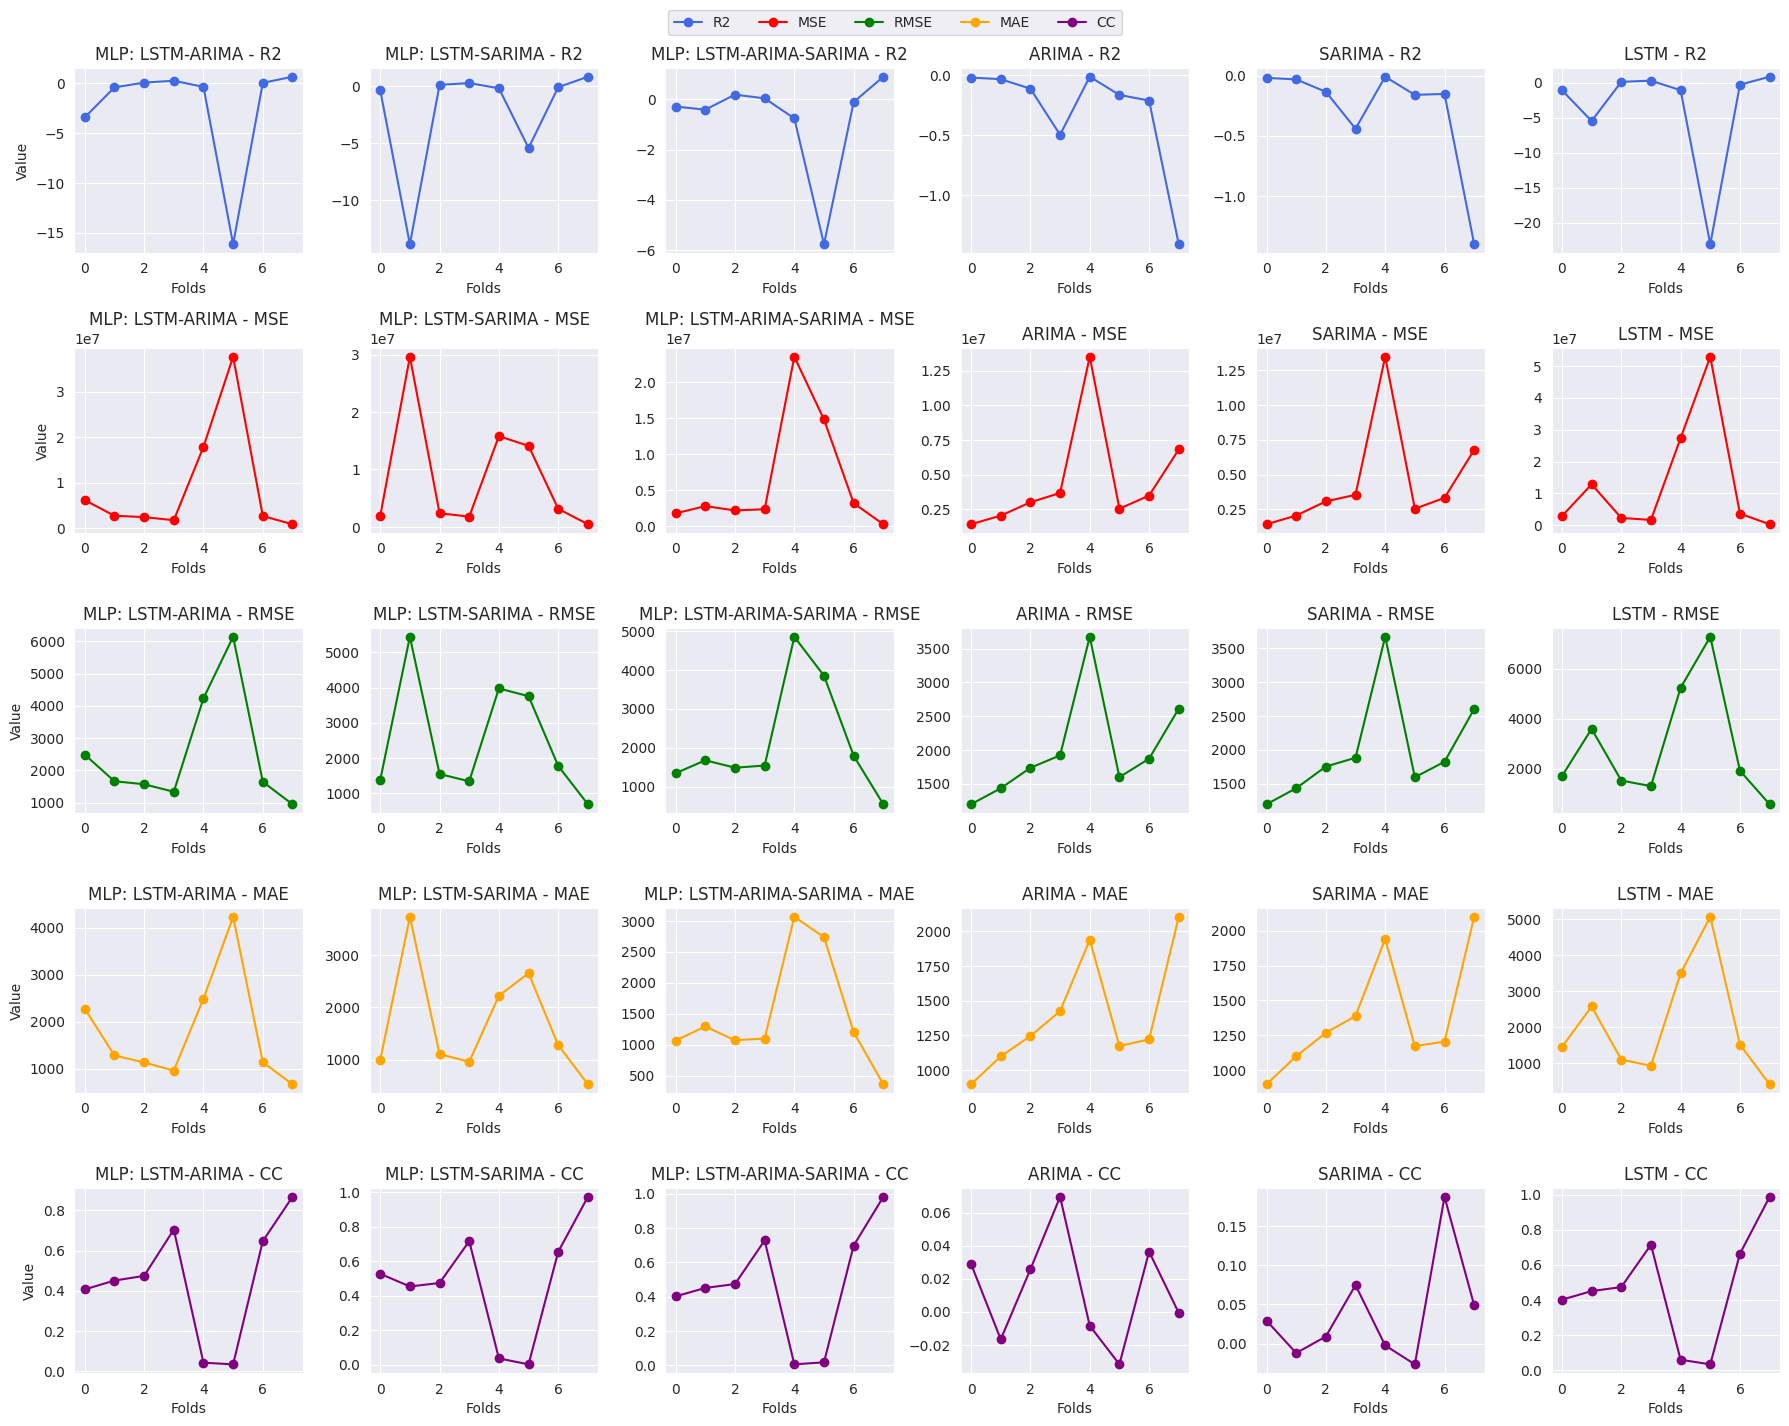

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)

kolom = ['r2','mse','rmse','mae','cc']

hasil = [
    df_result_lstm_arima,
    df_result_lstm_sarima,
    df_result_lstm_arima_sarima,
    df_result_arima,
    df_result_sarima,
    df_result_lstm
]

nama_model = [
    'MLP: LSTM-ARIMA',
    'MLP: LSTM-SARIMA',
    'MLP: LSTM-ARIMA-SARIMA',
    'ARIMA',
    'SARIMA',
    'LSTM'
]

# 🎨 WARNA KHUSUS PER METRIK
warna_metric = {
    'r2': 'royalblue',
    'mse': 'red',
    'rmse': 'green',
    'mae': 'orange',
    'cc': 'purple'
}

n_rows = len(kolom)
n_cols = len(hasil)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 14), sharex=True)

for i, metric in enumerate(kolom):      # baris = metrik
    for j, df in enumerate(hasil):      # kolom = model

        axes[i, j].plot(
            df[metric],
            marker='o',
            color=warna_metric[metric]   # 🔥 warna berdasarkan METRIK
        )

        axes[i, j].set_title(f"{nama_model[j]} - {metric.upper()}")
        axes[i, j].grid(True)

        axes[i, j].set_xlabel("Folds")
        axes[i, j].tick_params(axis='x', labelbottom=True)

        if j == 0:
            axes[i, j].set_ylabel("Value")

# 🔥 LEGEND GLOBAL DI ATAS TENGAH
handles = [
    plt.Line2D([0], [0], color=warna_metric[m], marker='o', label=m.upper())
    for m in kolom
]

fig.legend(
    handles=handles,
    loc='upper center',
    ncol=len(kolom),
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()
plt.savefig('FOLDS METRICS RESULTS : LINE STYLE.jpg', dpi=800)
plt.show()


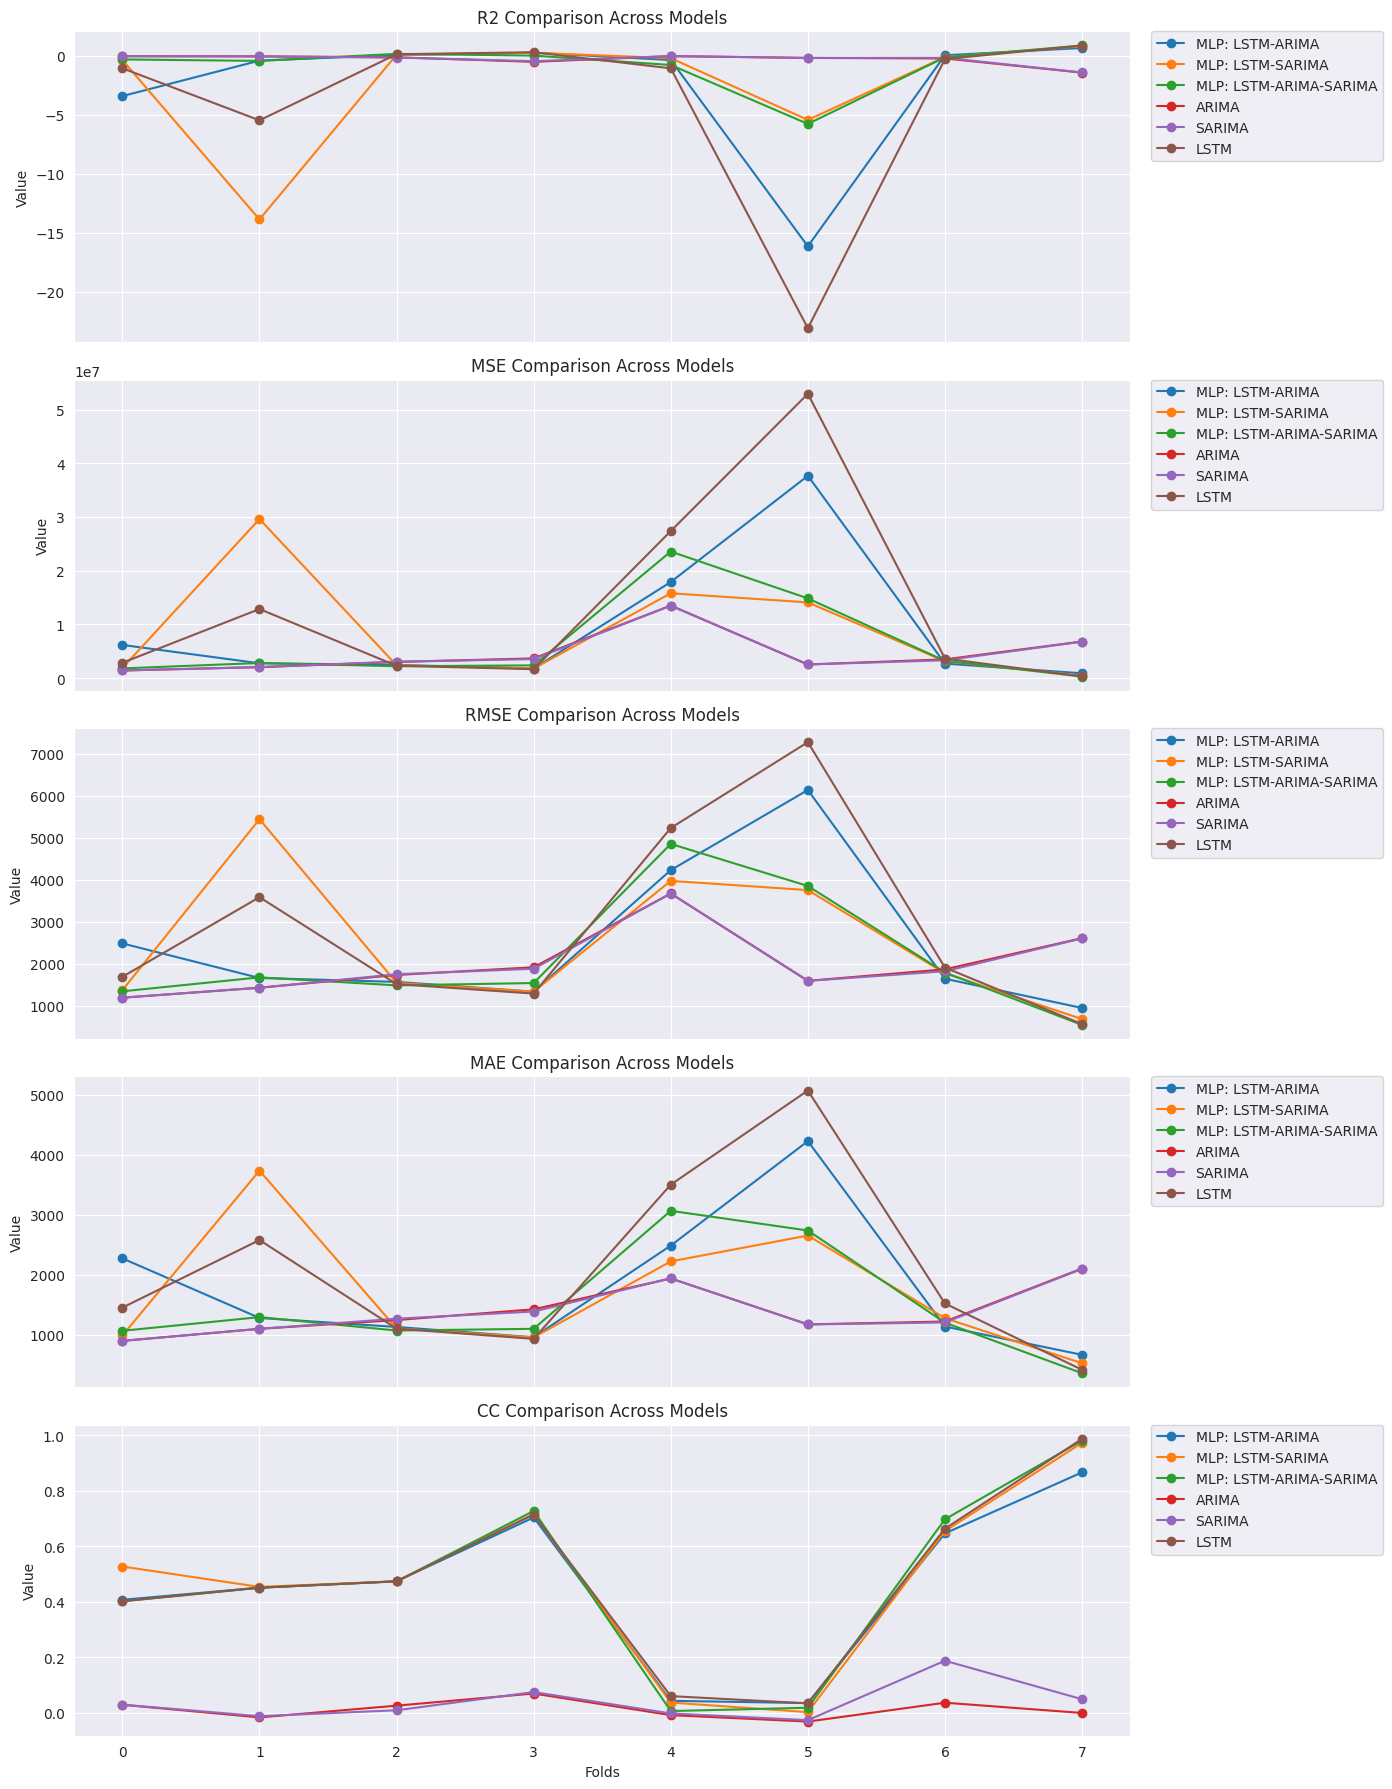

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)

kolom = ['r2','mse','rmse','mae','cc']

hasil = [
    df_result_lstm_arima,
    df_result_lstm_sarima,
    df_result_lstm_arima_sarima,
    df_result_arima,
    df_result_sarima,
    df_result_lstm
]

nama_model = [
    'MLP: LSTM-ARIMA',
    'MLP: LSTM-SARIMA',
    'MLP: LSTM-ARIMA-SARIMA',
    'ARIMA',
    'SARIMA',
    'LSTM'
]

n_rows = len(kolom)

fig, axes = plt.subplots(n_rows, 1, figsize=(14, 18), sharex=True)

for i, metric in enumerate(kolom):

    for df, nama in zip(hasil, nama_model):
        axes[i].plot(df[metric], marker='o', label=nama)

    axes[i].set_title(f"{metric.upper()} Comparison Across Models")
    axes[i].set_ylabel("Value")
    axes[i].grid(True)

    # 🔥 LEGEND DI KANAN LUAR
    axes[i].legend(
        loc='upper left',
        bbox_to_anchor=(1.02, 1),  # 👉 kanan luar
        borderaxespad=0,
        frameon=True
    )

axes[-1].set_xlabel("Folds")

# 🔥 BIKIN RUANG DI KANAN BUAT LEGEND
plt.subplots_adjust(right=0.78)

plt.tight_layout()
plt.savefig('FOLDS METRICS RESULTS : LINE STYLE (STACKED STYLE).jpg', dpi=800)
plt.show()


## B) MONITOR EACH FOLDS - BAR PLOT

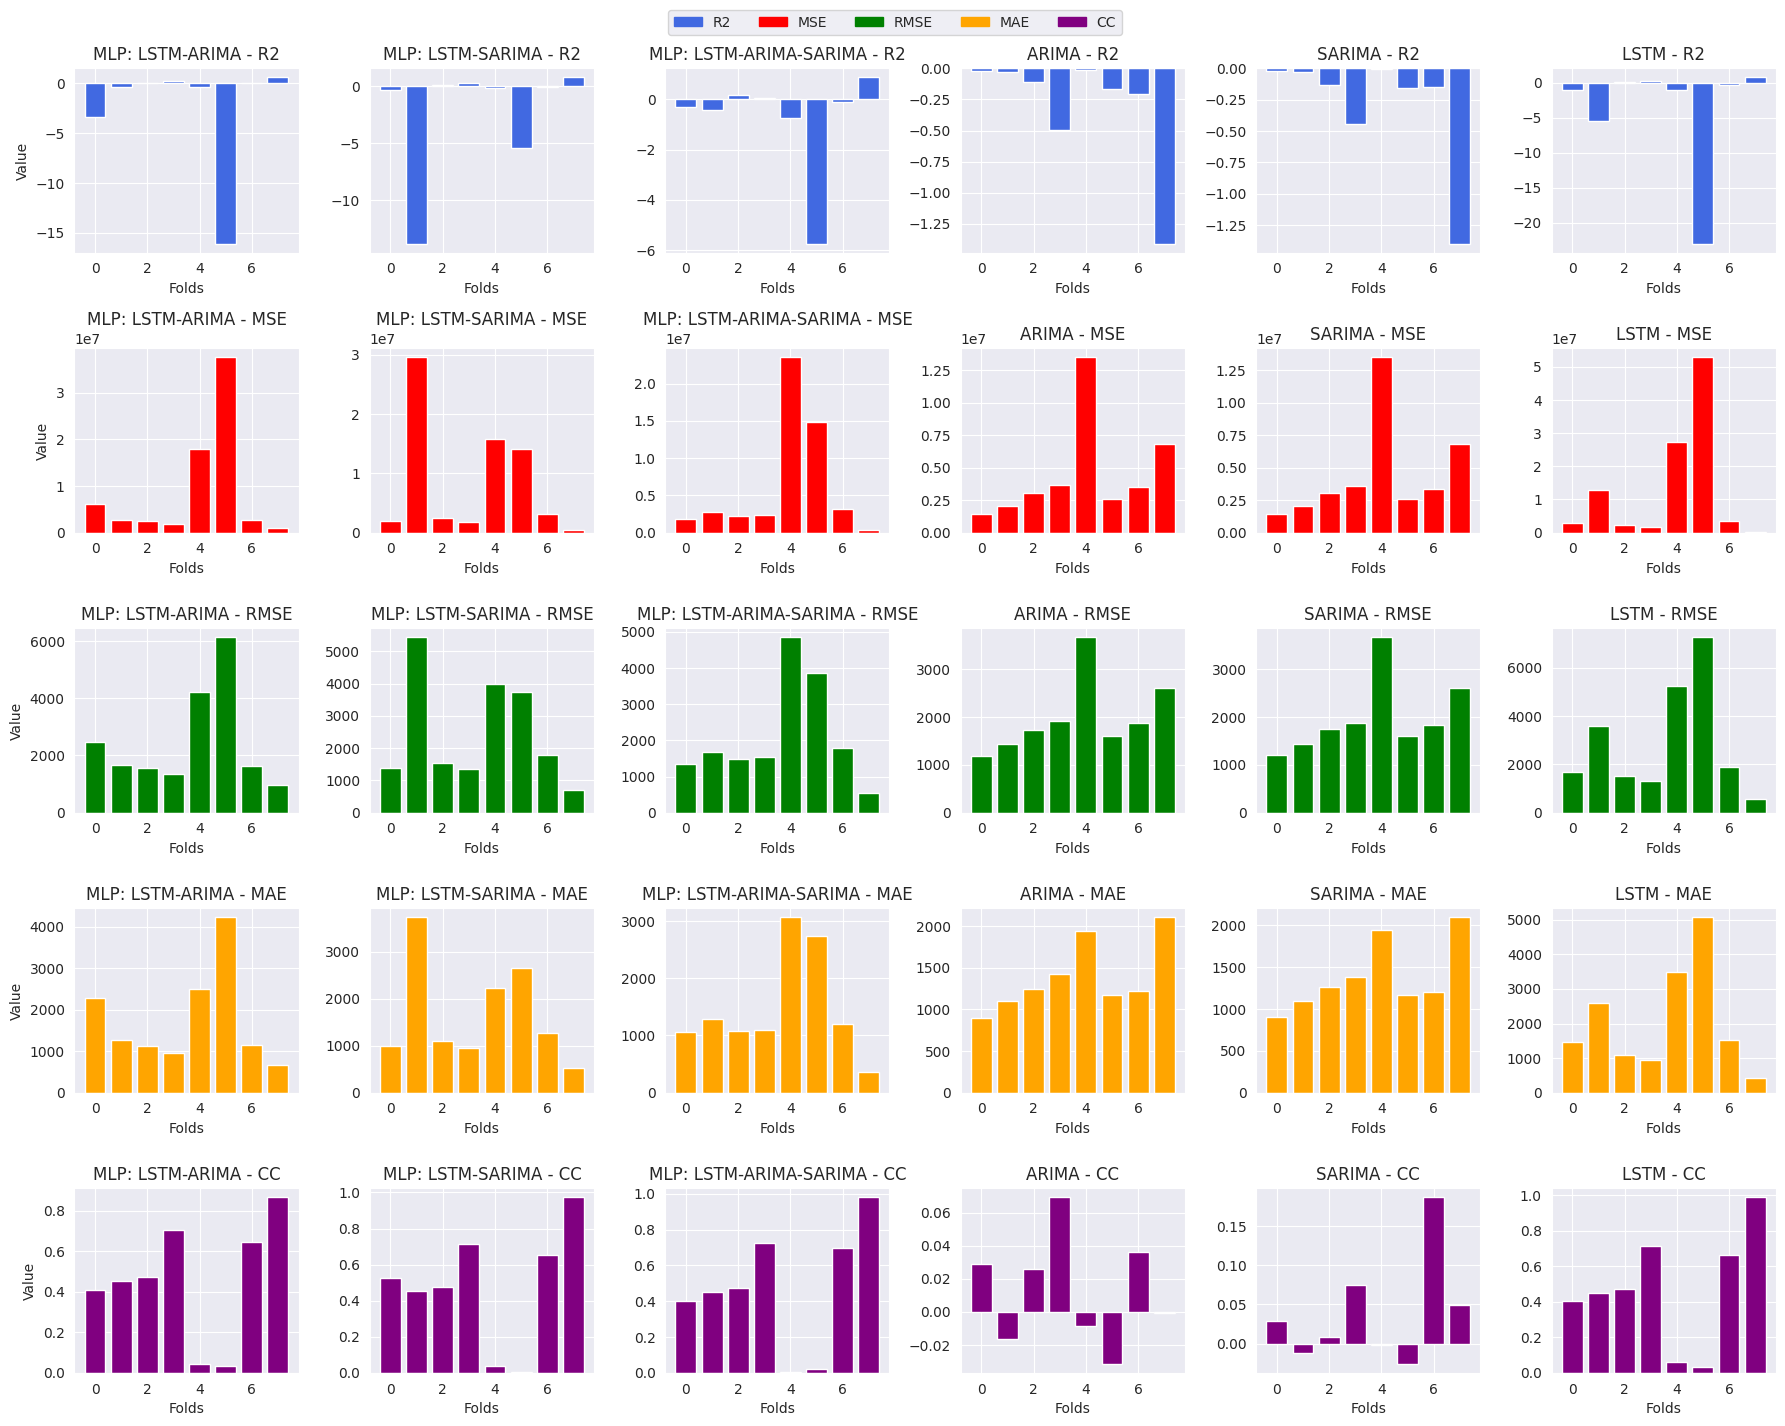

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)

kolom = ['r2','mse','rmse','mae','cc']

hasil = [
    df_result_lstm_arima,
    df_result_lstm_sarima,
    df_result_lstm_arima_sarima,
    df_result_arima,
    df_result_sarima,
    df_result_lstm
]

nama_model = [
    'MLP: LSTM-ARIMA',
    'MLP: LSTM-SARIMA',
    'MLP: LSTM-ARIMA-SARIMA',
    'ARIMA',
    'SARIMA',
    'LSTM'
]

# 🎨 WARNA KHUSUS PER METRIK
warna_metric = {
    'r2': 'royalblue',
    'mse': 'red',
    'rmse': 'green',
    'mae': 'orange',
    'cc': 'purple'
}

n_rows = len(kolom)
n_cols = len(hasil)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 14), sharex=True)

for i, metric in enumerate(kolom):      # baris = metrik
    for j, df in enumerate(hasil):      # kolom = model

        axes[i, j].bar(
            df.index,                 # X = fold
            df[metric],               # Y = nilai metric
            color=warna_metric[metric]
        )

        axes[i, j].set_title(f"{nama_model[j]} - {metric.upper()}")
        axes[i, j].grid(True, axis='y')   # grid horizontal lebih cocok utk bar

        axes[i, j].set_xlabel("Folds")
        axes[i, j].tick_params(axis='x', labelbottom=True)

        if j == 0:
            axes[i, j].set_ylabel("Value")

# 🔥 LEGEND GLOBAL DI ATAS TENGAH
handles = [
    plt.Rectangle((0,0),1,1,color=warna_metric[m], label=m.upper())
    for m in kolom
]

fig.legend(
    handles=handles,
    loc='upper center',
    ncol=len(kolom),
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()
plt.savefig('FOLDS_METRICS_RESULTS_BAR_STYLE.jpg', dpi=800)
plt.show()


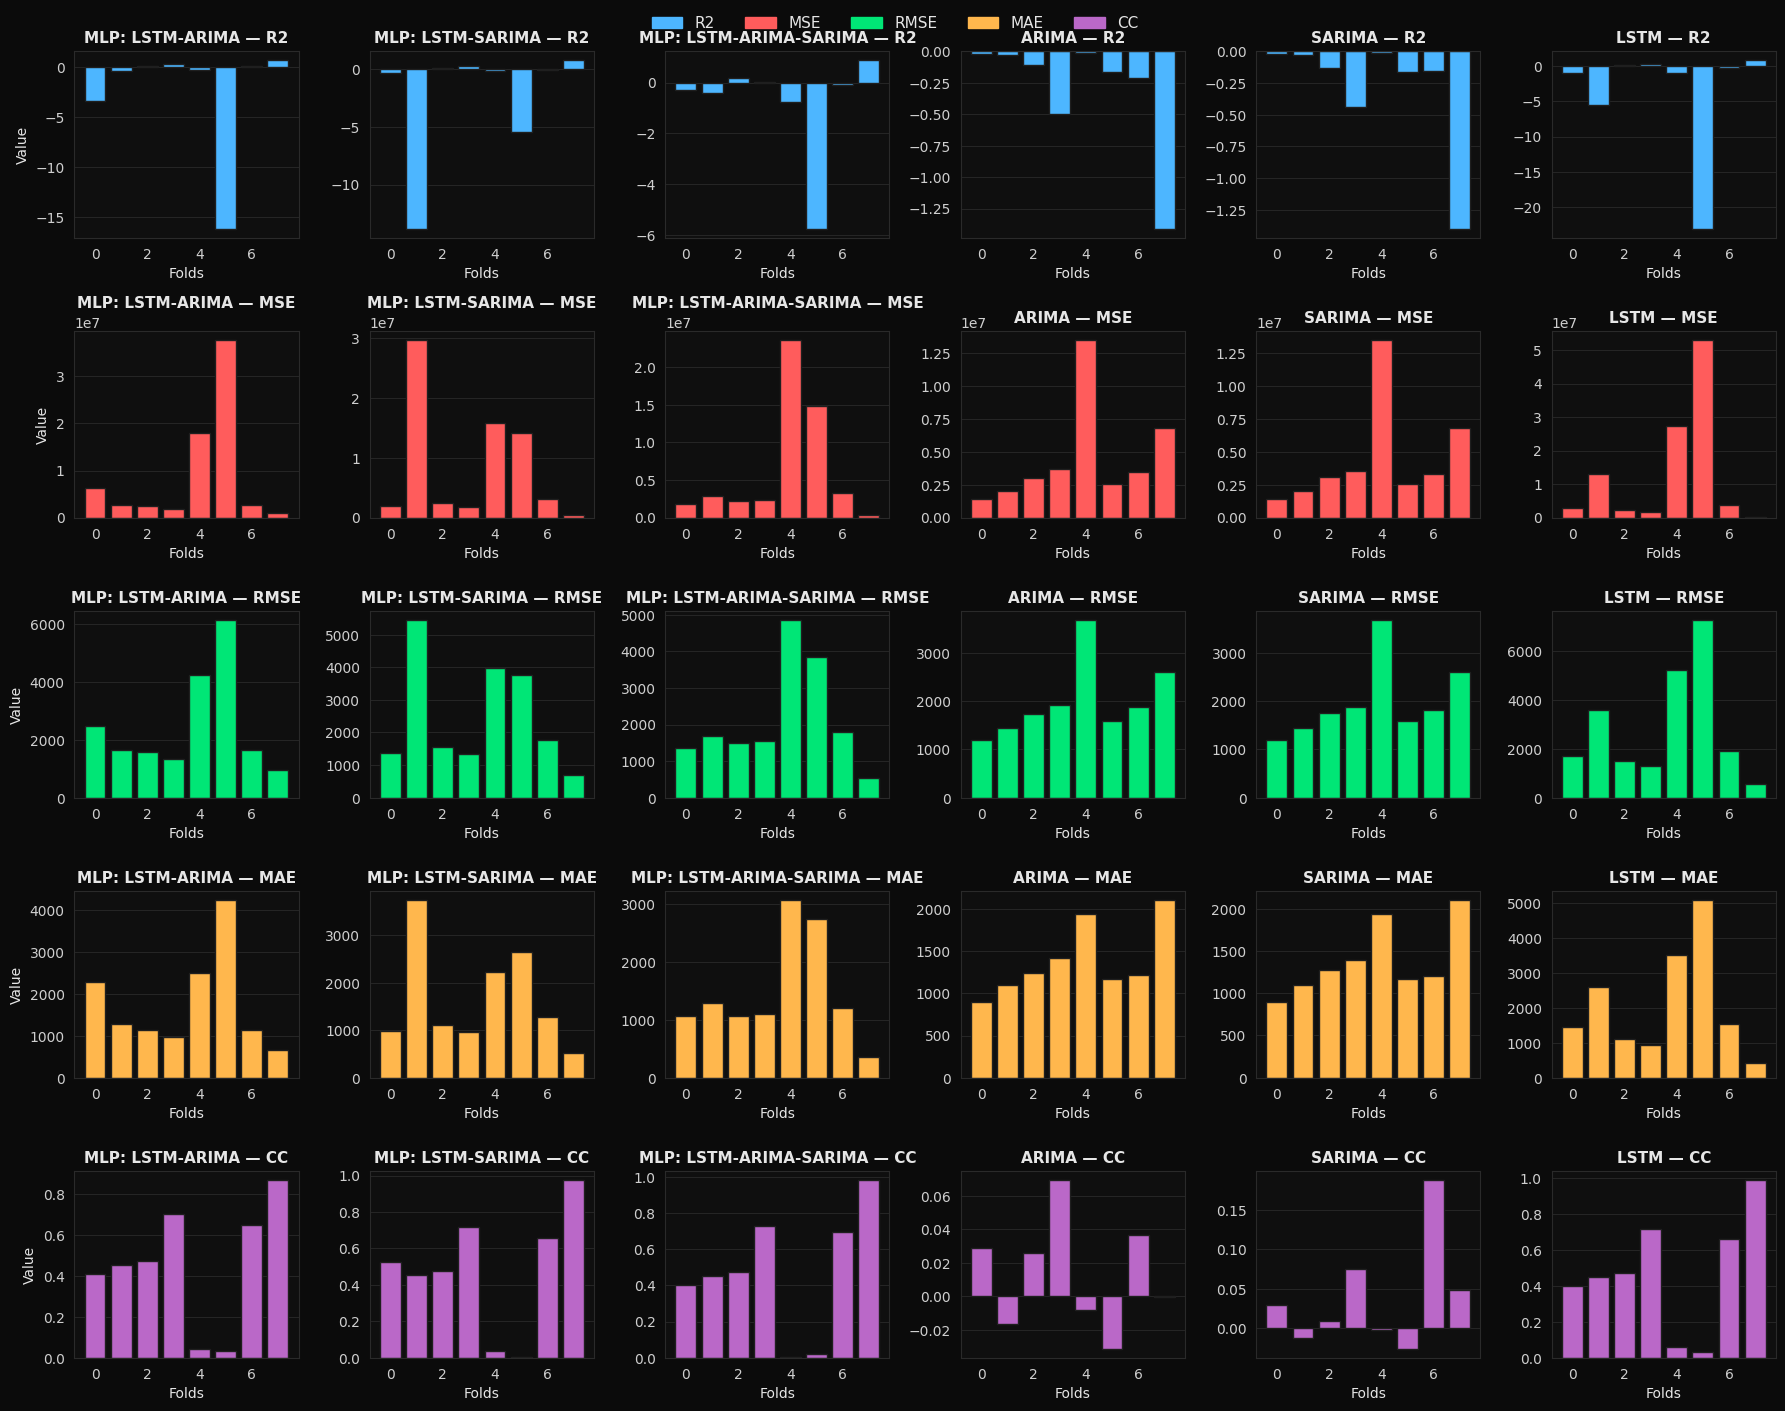

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 🖥️ BLOOMBERG DARK STYLE
# =========================
plt.style.use('dark_background')
sns.set_style("white")  # matikan seaborn grid default

plt.rcParams.update({
    'figure.figsize': (18, 14),
    'axes.facecolor': '#0F0F0F',     # panel gelap
    'figure.facecolor': '#0B0B0B',   # background utama
    'axes.edgecolor': '#2A2A2A',
    'axes.labelcolor': '#E6E6E6',
    'xtick.color': '#CFCFCF',
    'ytick.color': '#CFCFCF',
    'text.color': '#E6E6E6',
    'font.size': 10
})

# =========================
# METRIK & DATA
# =========================
kolom = ['r2','mse','rmse','mae','cc']

hasil = [
    df_result_lstm_arima,
    df_result_lstm_sarima,
    df_result_lstm_arima_sarima,
    df_result_arima,
    df_result_sarima,
    df_result_lstm
]

nama_model = [
    'MLP: LSTM-ARIMA',
    'MLP: LSTM-SARIMA',
    'MLP: LSTM-ARIMA-SARIMA',
    'ARIMA',
    'SARIMA',
    'LSTM'
]

# =========================
# 🎨 WARNA METRIK — BLOOMBERG DARK SAFE
# =========================
warna_metric = {
    'r2':  '#4DB6FF',  # neon blue
    'mse': '#FF5C5C',  # soft red
    'rmse':'#00E676',  # terminal green
    'mae': '#FFB74D',  # amber
    'cc':  '#BA68C8'   # purple
}

# =========================
# SUBPLOT
# =========================
n_rows = len(kolom)
n_cols = len(hasil)

fig, axes = plt.subplots(n_rows, n_cols, sharex=True)

for i, metric in enumerate(kolom):      # baris = metrik
    for j, df in enumerate(hasil):      # kolom = model

        ax = axes[i, j]

        ax.bar(
            df.index,
            df[metric],
            color=warna_metric[metric],
            edgecolor='#1F1F1F'
        )

        # 🪶 GRID TIPIS ALA TERMINAL
        ax.grid(True, axis='y', color='#2A2A2A', linewidth=0.6)

        ax.set_title(
            f"{nama_model[j]} — {metric.upper()}",
            fontsize=11,
            weight='bold'
        )

        ax.set_xlabel("Folds")
        ax.tick_params(axis='x', labelbottom=True)

        if j == 0:
            ax.set_ylabel("Value")

# =========================
# 🔥 LEGEND GLOBAL — BLOOMBERG STYLE
# =========================
handles = [
    plt.Rectangle((0,0),1,1,color=warna_metric[m], label=m.upper())
    for m in kolom
]

fig.legend(
    handles=handles,
    loc='upper center',
    ncol=len(kolom),
    bbox_to_anchor=(0.5, 1.01),
    frameon=False,
    fontsize=11
)

plt.tight_layout()
# plt.savefig('FOLDS_METRICS_RESULTS_BAR_BLOOMBERG_DARK.jpg', dpi=800)
plt.show()


## C) MODEL COMPARISON : METRICS & STABILITY  

In [80]:
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from matplotlib import cm
# import math

# # =========================
# # STYLE
# # =========================
# sns.set_style('darkgrid')
# plt.rcParams['figure.figsize'] = (10, 8)

# # =========================
# # KONFIGURASI
# # =========================
# kolom = ['r2', 'mse', 'rmse', 'mae', 'cc']

# hasil = [
#     df_result_lstm_arima,
#     df_result_lstm_sarima,
#     df_result_lstm_arima_sarima,
#     df_result_arima,
#     df_result_sarima,
#     df_result_lstm
# ]

# nama_model = [
#     'MLP: LSTM-ARIMA',
#     'MLP: LSTM-SARIMA',
#     'MLP: LSTM-ARIMA-SARIMA',
#     'ARIMA',
#     'SARIMA',
#     'LSTM'
# ]

# n_cols = 2
# n_rows = math.ceil(len(kolom) / n_cols)

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10), sharex=True)

# colors = cm.viridis(np.linspace(0.2, 0.8, len(hasil)))

# # =========================
# # LOOP PLOT
# # =========================
# for i, metric in enumerate(kolom):

#     row = i // n_cols
#     col = i % n_cols

#     data = [df[metric].values for df in hasil]

#     # 🔥 KUNCI KERAPATAN
#     positions = np.arange(1, len(data) + 1) * 0.8

#     box = axes[row, col].boxplot(
#         data,
#         positions=positions,
#         widths=0.5,
#         patch_artist=True
#     )

#     for patch, color in zip(box['boxes'], colors):
#         patch.set_facecolor(color)

#     axes[row, col].set_title(metric.upper())
#     axes[row, col].set_ylabel("Value")
#     axes[row, col].set_xlabel("Model")

#     axes[row, col].grid(True, axis='y')

#     axes[row, col].set_xticks(positions)
#     axes[row, col].set_xticklabels(nama_model, rotation=70)

#     # pastikan label x tetap muncul walau sharex
#     axes[row, col].tick_params(axis='x', labelbottom=True)

# # =========================
# # HAPUS SUBPLOT KOSONG
# # =========================
# if len(kolom) % n_cols != 0:
#     fig.delaxes(axes[-1, -1])

# plt.tight_layout()
# # plt.savefig('STABILITY COMPARISON AFTER FOLDS : PROPOSED_vs_SARIMA_vs_LSTM.jpg', dpi=800)
# plt.show()


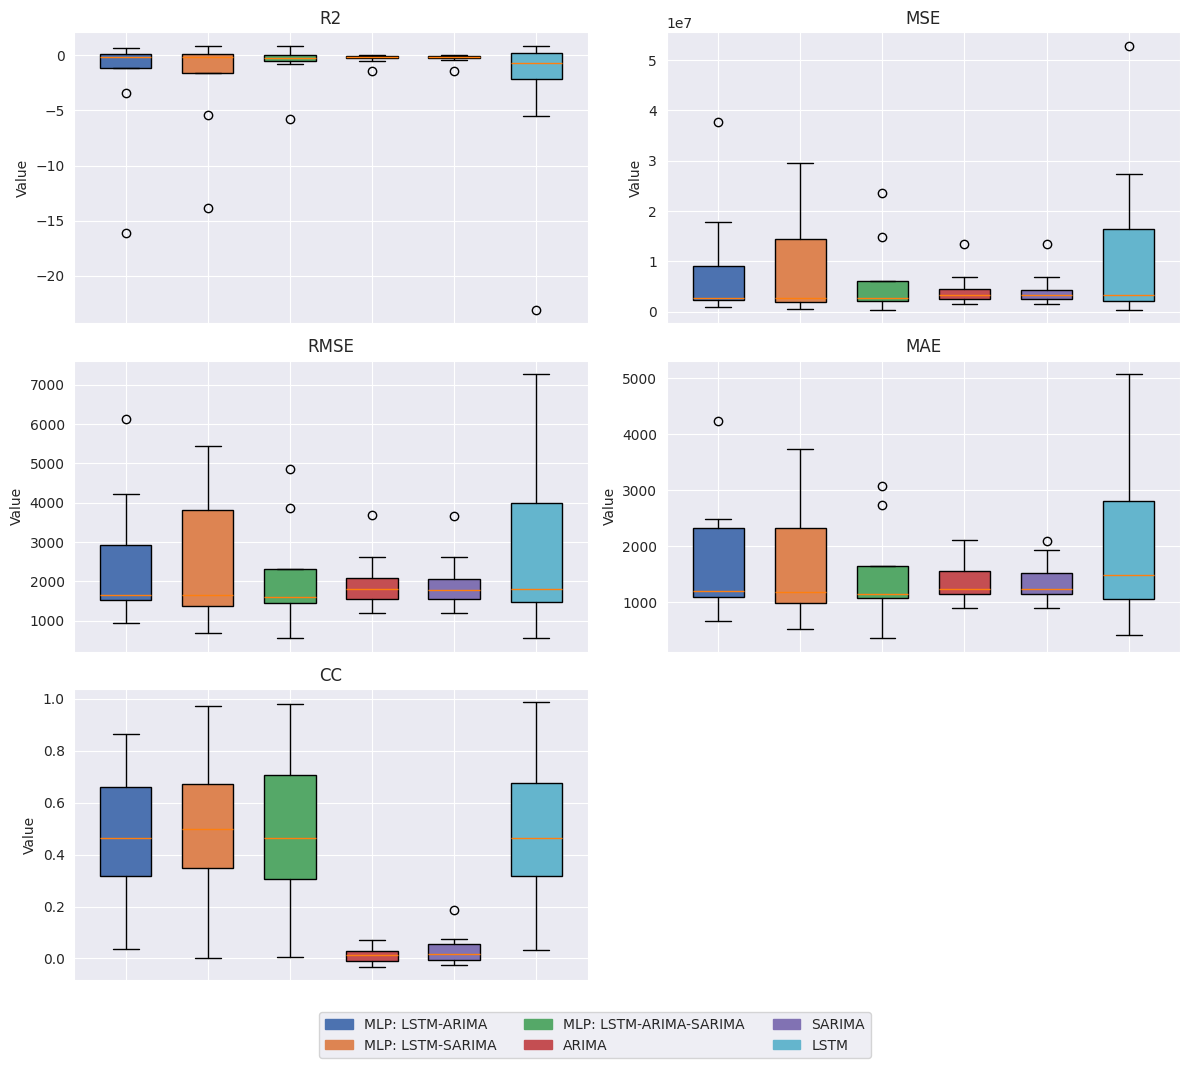

In [87]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

# =========================
# STYLE
# =========================
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 8)

# =========================
# KONFIGURASI
# =========================
kolom = ['r2', 'mse', 'rmse', 'mae', 'cc']

hasil = [
    df_result_lstm_arima,
    df_result_lstm_sarima,
    df_result_lstm_arima_sarima,
    df_result_arima,
    df_result_sarima,
    df_result_lstm
]

nama_model = [
    'MLP: LSTM-ARIMA',
    'MLP: LSTM-SARIMA',
    'MLP: LSTM-ARIMA-SARIMA',
    'ARIMA',
    'SARIMA',
    'LSTM'
]

# 🎨 WARNA SOFT UNIK PER MODEL (NO GRADASI)
colors = [
    '#4C72B0',  # muted blue
    '#DD8452',  # soft orange
    '#55A868',  # sage green
    '#C44E52',  # dusty red
    '#8172B3',  # purple gray
    '#64B5CD'   # soft teal
]

n_cols = 2
n_rows = math.ceil(len(kolom) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10), sharex=True)

# =========================
# LOOP PLOT
# =========================
for i, metric in enumerate(kolom):

    row = i // n_cols
    col = i % n_cols

    data = [df[metric].values for df in hasil]

    positions = np.arange(1, len(data) + 1) * 0.8

    box = axes[row, col].boxplot(
        data,
        positions=positions,
        widths=0.5,
        patch_artist=True
    )

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    axes[row, col].set_title(metric.upper())
    axes[row, col].set_ylabel("Value")
    axes[row, col].grid(True, axis='y')

    axes[row, col].set_xticks(positions)
    axes[row, col].set_xticklabels([])
    axes[row, col].tick_params(axis='x', labelbottom=False)

# =========================
# LEGEND GLOBAL (BAWAH TENGAH)
# =========================
legend_handles = [
    mpatches.Patch(color=color, label=nama)
    for color, nama in zip(colors, nama_model)
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.07),
    frameon=True
)

# =========================
# HAPUS SUBPLOT KOSONG
# =========================
if len(kolom) % n_cols != 0:
    fig.delaxes(axes[-1, -1])

plt.tight_layout()
plt.savefig('STABILITY COMPARISON AFTER FOLDS : 3 PROPOSED BEST_vs_SARIMA_vs_LSTM.jpg', dpi=800)
plt.show()


## D) LINE PLOT PREDICTION VS ACTUAL : MLP-LSTM-SARIMA

In [90]:
df_meta1

,fold,actual,prediction
0,0,12000.0,9664.449219
1,0,12000.0,9909.598633
2,0,12000.0,9781.670898
3,0,11975.0,9591.055664
4,0,13000.0,10020.416992
...,...,...,...
3259,7,13938.0,14502.114258
3260,7,14416.0,14947.515625
3261,7,14650.0,15164.988281
3262,7,14750.0,15254.244141


In [91]:
df_meta2

,fold,actual,prediction
0,0,12000.0,11702.474609
1,0,12000.0,11720.010742
2,0,12000.0,11710.508789
3,0,11975.0,11698.447266
4,0,13000.0,11709.442383
...,...,...,...
3259,7,13938.0,14520.322266
3260,7,14416.0,14839.107422
3261,7,14650.0,14994.758789
3262,7,14750.0,15058.641602


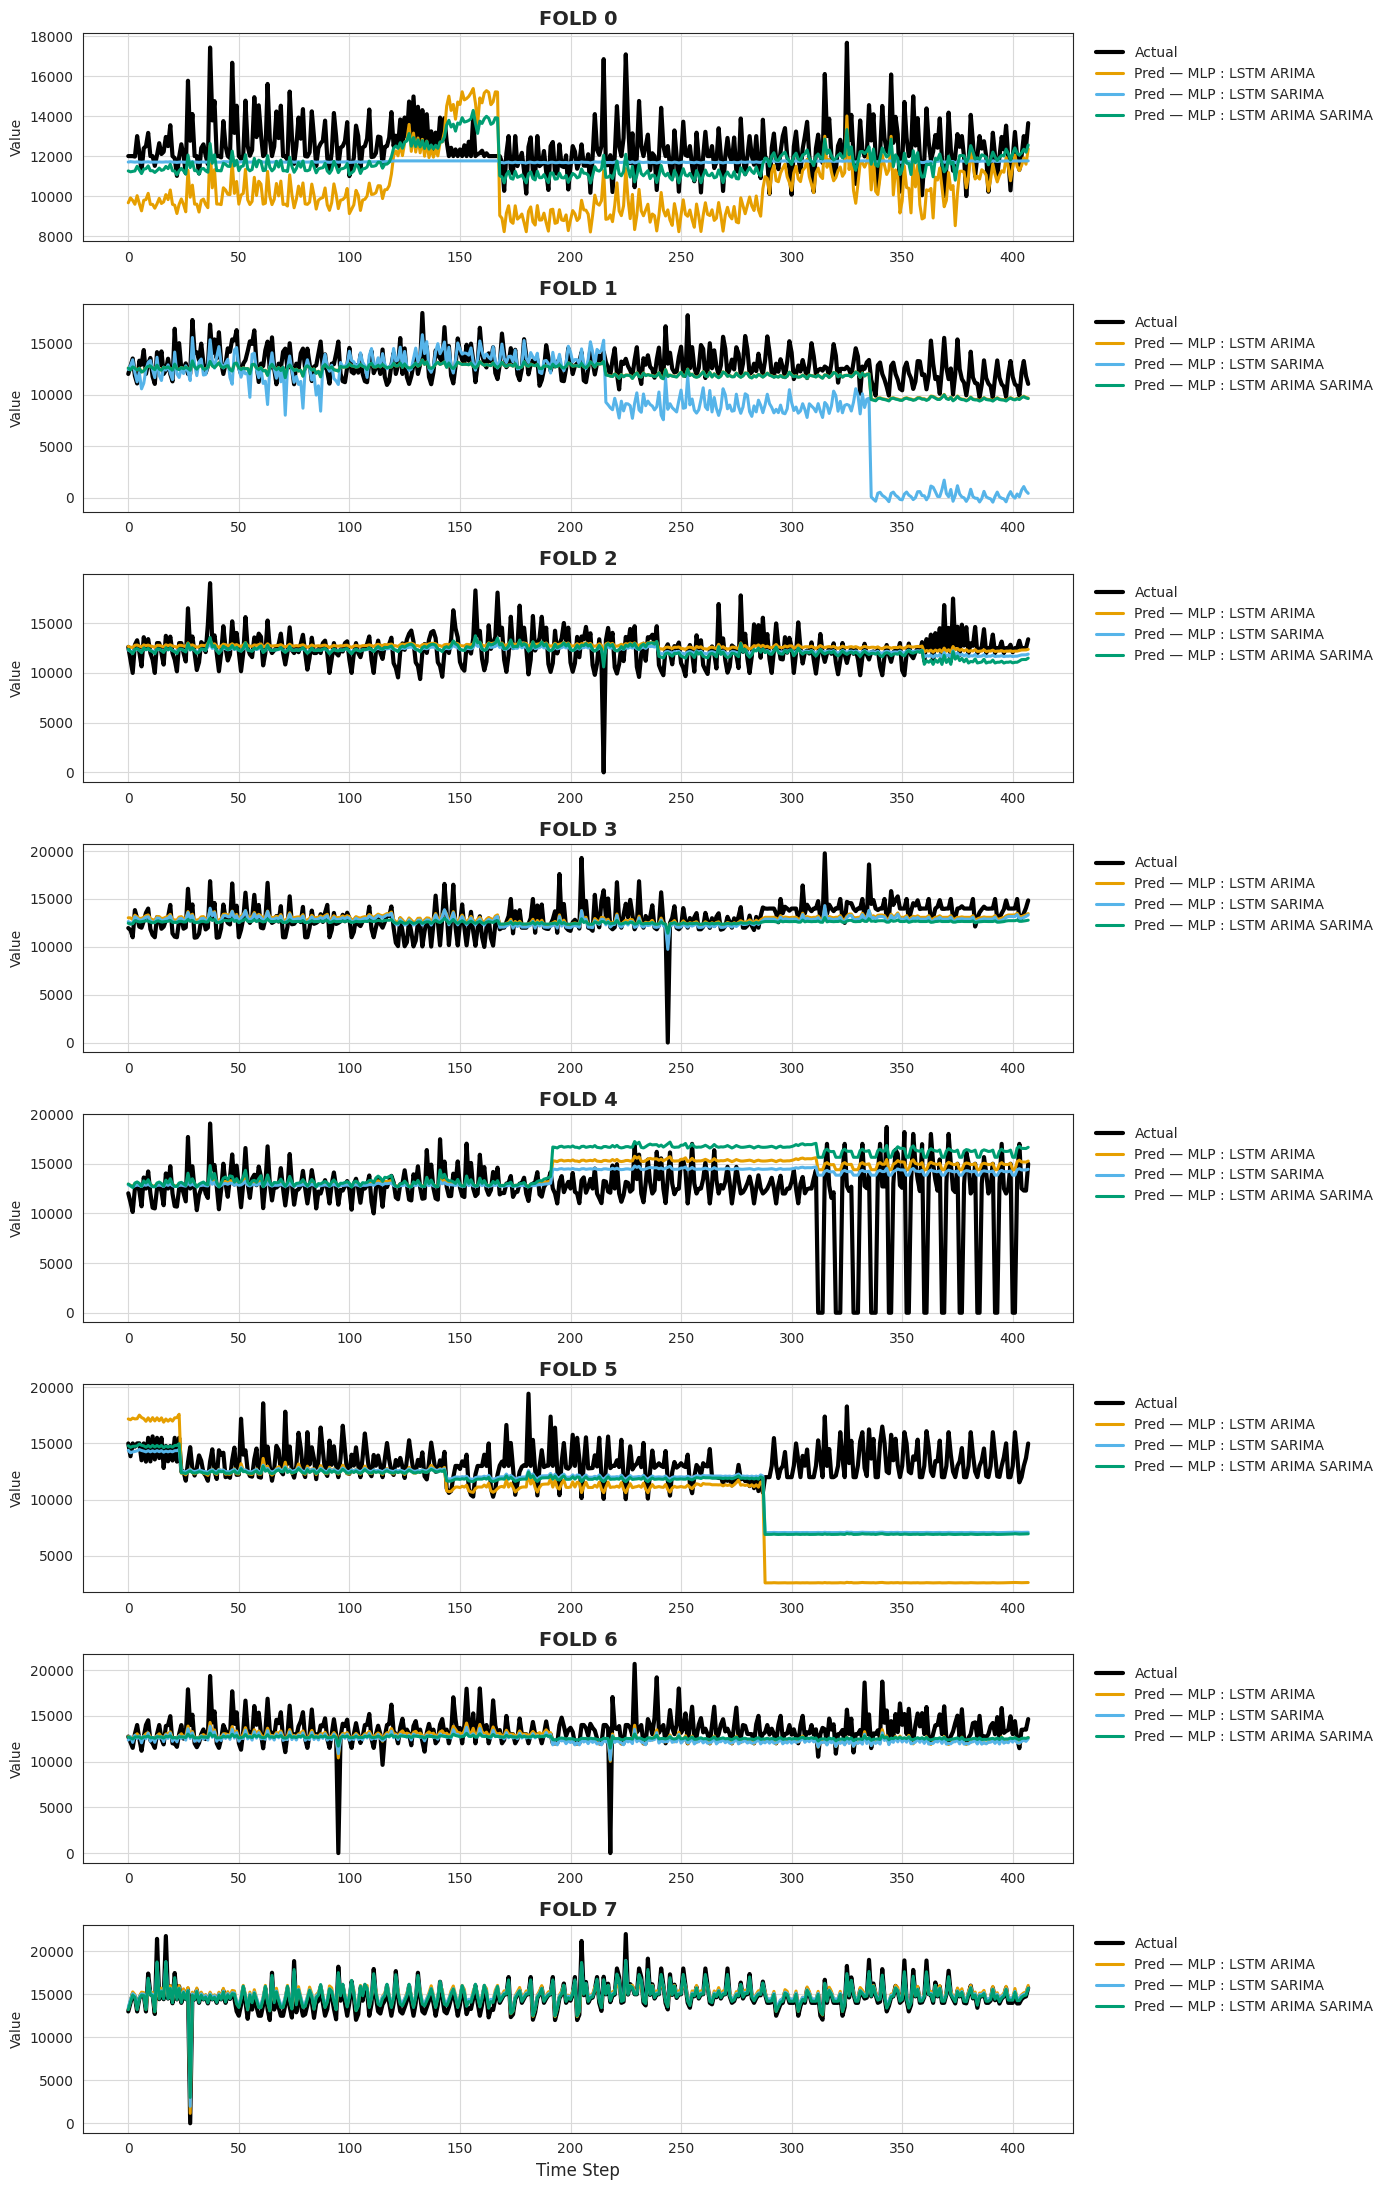

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 🧠 BLOOMBERG STYLE
# =========================
sns.set_style("white")  # bersih tanpa grid seaborn default

# =========================
# 🎨 BLOOMBERG PALETTE
# =========================
palette = [
    '#E69F00',  # yellow/orange
    '#56B4E9',  # blue
    '#009E73'   # teal
]

# =========================
# NAMA MODEL
# =========================
model_names = [
    "MLP : LSTM ARIMA",
    "MLP : LSTM SARIMA",
    "MLP : LSTM ARIMA SARIMA"
]

dfs = [df_meta1, df_meta2, df_meta3]

# =========================
# AMBIL JUMLAH FOLD
# =========================
folds = sorted(df_meta1['fold'].unique())

fig, axes = plt.subplots(len(folds), 1, figsize=(14, 22), sharex=False)

if len(folds) == 1:
    axes = [axes]

# =========================
# LOOP PER FOLD
# =========================
for i, fold in enumerate(folds):

    ax = axes[i]

    d1 = df_meta1[df_meta1['fold'] == fold]
    d2 = df_meta2[df_meta2['fold'] == fold]
    d3 = df_meta3[df_meta3['fold'] == fold]

    # 🔲 GRID TIPIS ABU (Bloomberg style)
    ax.grid(True, color='#D9D9D9', linewidth=0.8)

    # =========================
    # ACTUAL — HITAM TEBAL
    # =========================
    ax.plot(
        d1['actual'].values,
        label="Actual",
        linewidth=3,
        color='black'
    )

    # =========================
    # PREDICT PER MODEL
    # =========================
    ax.plot(d1['prediction'].values,
            label=f"Pred — {model_names[0]}",
            color=palette[0],
            linewidth=2.2)

    ax.plot(d2['prediction'].values,
            label=f"Pred — {model_names[1]}",
            color=palette[1],
            linewidth=2.2)

    ax.plot(d3['prediction'].values,
            label=f"Pred — {model_names[2]}",
            color=palette[2],
            linewidth=2.2)

    # TITLE GAYA NEWSROOM
    ax.set_title(f"FOLD {fold}", fontsize=14, weight='bold')

    ax.set_ylabel("Value")

    # Legend kanan luar
    ax.legend(
        loc='upper left',
        bbox_to_anchor=(1.01, 1),
        frameon=False  # Bloomberg biasanya tanpa box
    )

axes[-1].set_xlabel("Time Step", fontsize=12)

plt.tight_layout()
plt.savefig('pred_vs_aktual_LINEPLOT(ALL 3 BEST MODELS).jpg', dpi=800)
plt.show()


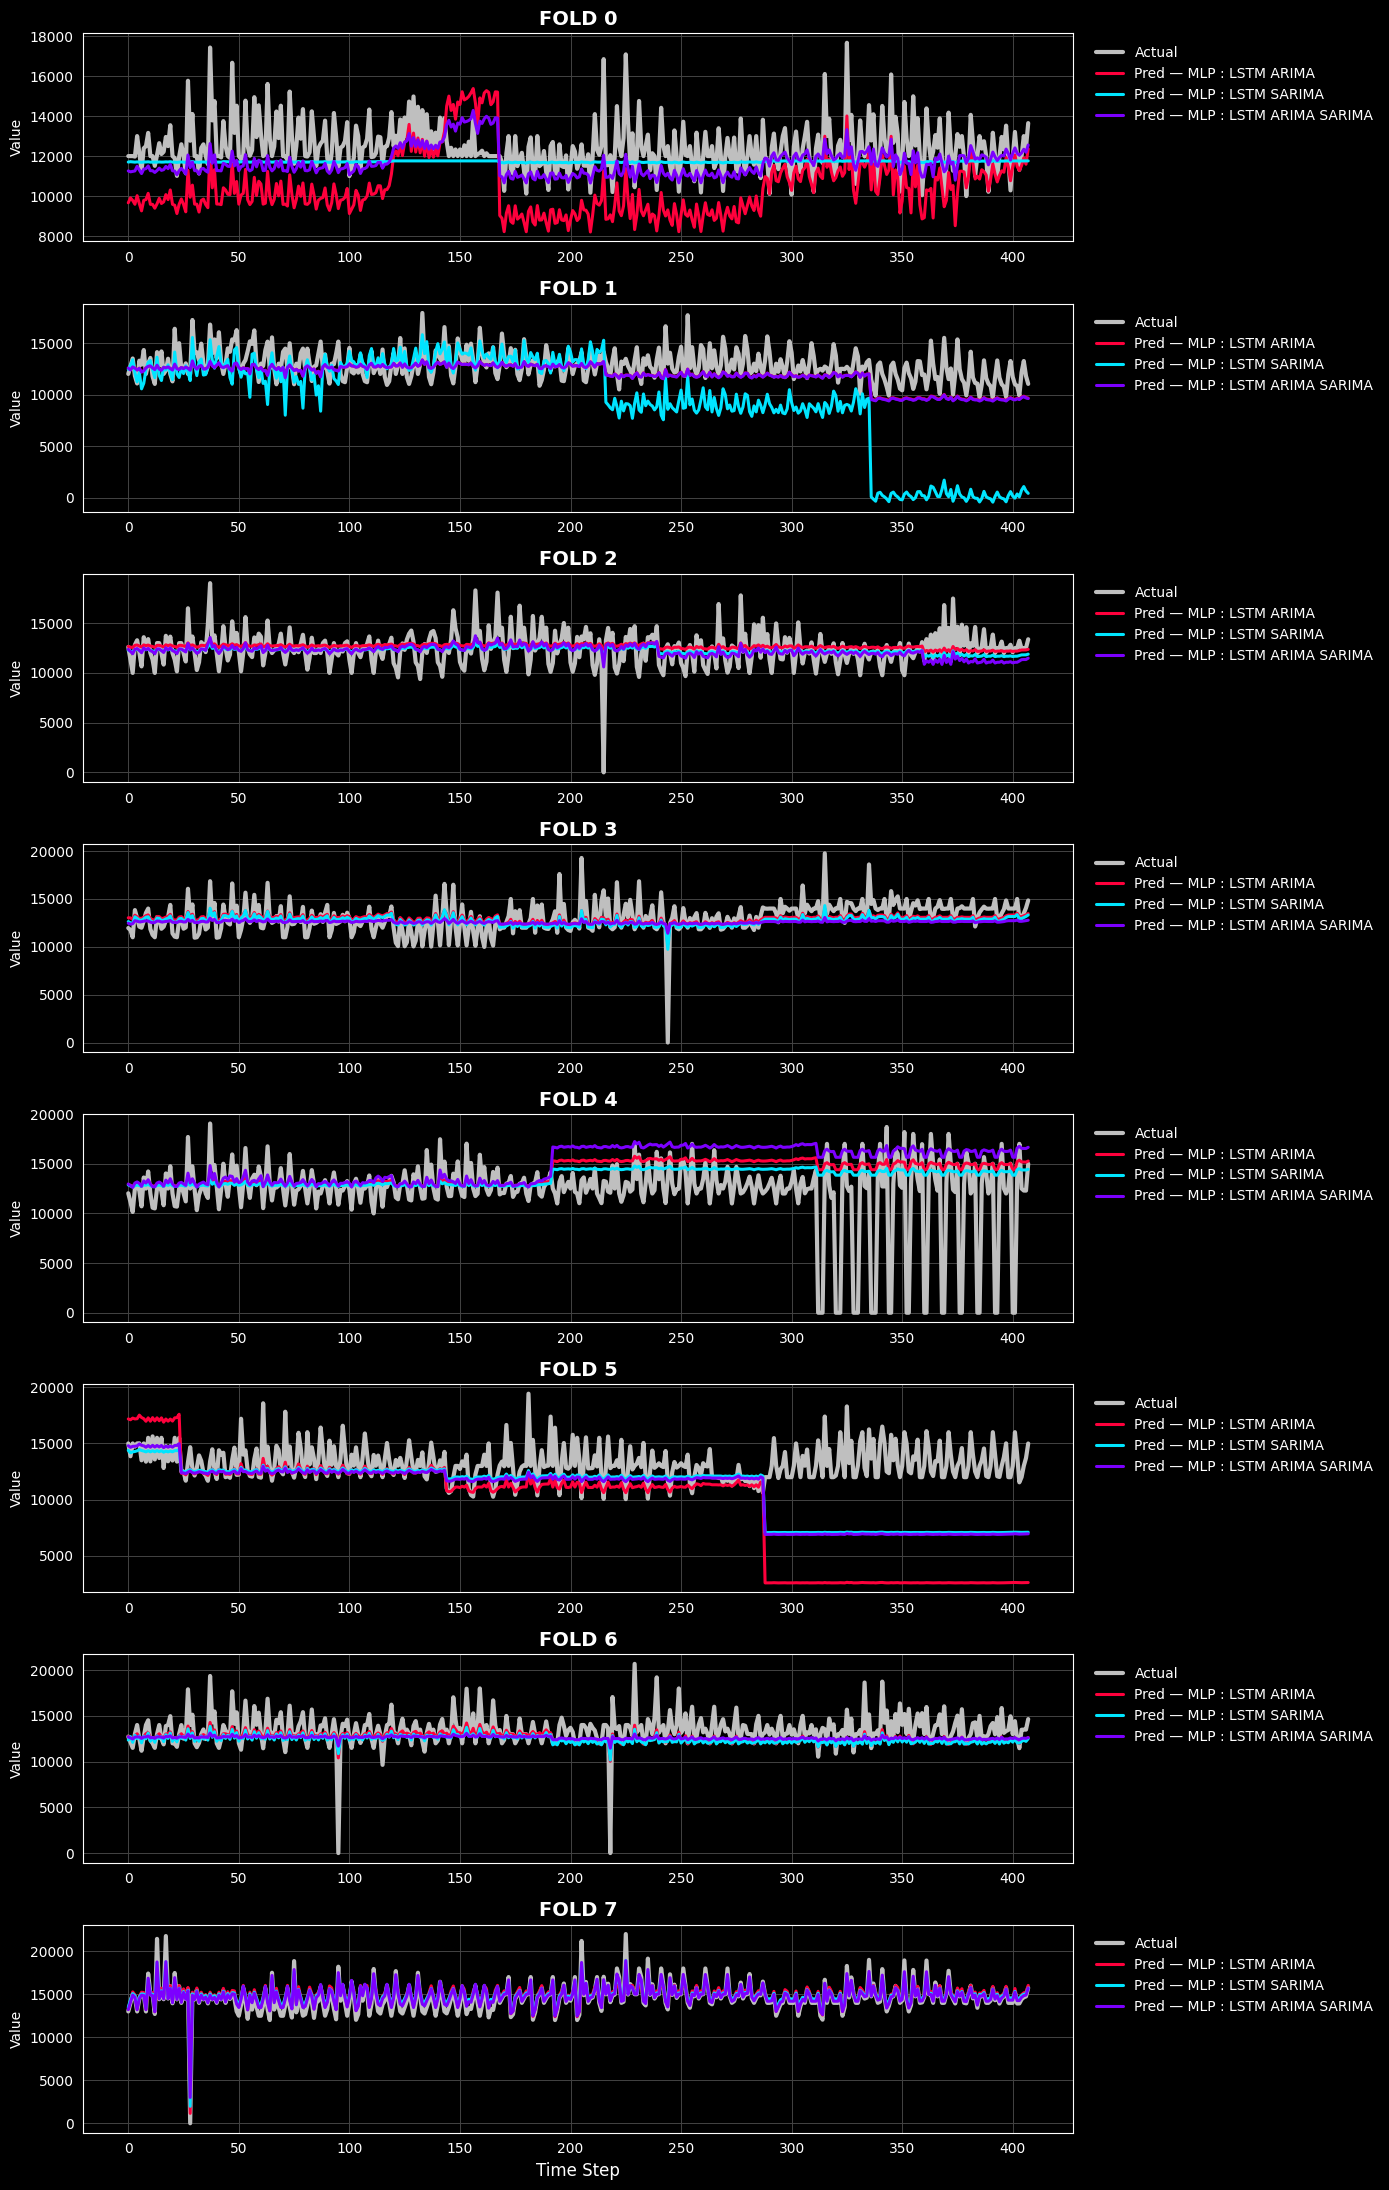

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 🧠 BLOOMBERG DARK TERMINAL STYLE
# =========================
plt.style.use('dark_background')  # background hitam

# =========================
# 🎨 BLOOMBERG DARK PALETTE
# =========================
palette = [
    '#FF003C',  # blood red
    '#00E5FF',  # ice cyan
    '#7C00FF'   # dark neon purple
]


color_actual = '#BFBFBF'  # dead silver
  # ghost grey

# =========================
# NAMA MODEL
# =========================
model_names = [
    "MLP : LSTM ARIMA",
    "MLP : LSTM SARIMA",
    "MLP : LSTM ARIMA SARIMA"
]

dfs = [df_meta1, df_meta2, df_meta3]

# =========================
# AMBIL JUMLAH FOLD
# =========================
folds = sorted(df_meta1['fold'].unique())

fig, axes = plt.subplots(len(folds), 1, figsize=(14, 22), sharex=False)

if len(folds) == 1:
    axes = [axes]

# =========================
# LOOP PER FOLD
# =========================
for i, fold in enumerate(folds):

    ax = axes[i]

    d1 = df_meta1[df_meta1['fold'] == fold]
    d2 = df_meta2[df_meta2['fold'] == fold]
    d3 = df_meta3[df_meta3['fold'] == fold]

    # 🔲 GRID TIPIS ABU GELAP
    ax.grid(True, color='#444444', linewidth=0.7)

    # =========================
    # ACTUAL — PUTIH TEBAL
    # =========================
    ax.plot(
        d1['actual'].values,
        label="Actual",
        linewidth=3,
        color=color_actual
    )

    # =========================
    # PREDICT PER MODEL
    # =========================
    ax.plot(d1['prediction'].values,
            label=f"Pred — {model_names[0]}",
            color=palette[0],
            linewidth=2.2)

    ax.plot(d2['prediction'].values,
            label=f"Pred — {model_names[1]}",
            color=palette[1],
            linewidth=2.2)

    ax.plot(d3['prediction'].values,
            label=f"Pred — {model_names[2]}",
            color=palette[2],
            linewidth=2.2)

    # =========================
    # TITLE STYLE NEWSROOM
    # =========================
    ax.set_title(f"FOLD {fold}", fontsize=14, weight='bold', color='white')

    ax.set_ylabel("Value", color='white')

    # warna tick putih
    ax.tick_params(colors='white')

    # Legend kanan luar, minimalis
    ax.legend(
        loc='upper left',
        bbox_to_anchor=(1.01, 1),
        frameon=False,
        labelcolor='white'
    )

axes[-1].set_xlabel("Time Step", fontsize=12, color='white')

plt.tight_layout()
plt.show()


## 1.2) STATISTICAL TEST - WILCOXON PAIRED-T-TEST

In [ ]:
from scipy.stats import wilcoxon

In [116]:
import pandas as pd
from itertools import combinations
from scipy.stats import wilcoxon

# List metric
kolom = ['r2', 'mse', 'rmse', 'mae', 'cc']

# Semua baseline models
baseline_models = {
    'LSTM': df_result_lstm,
    'SARIMA': df_result_sarima,
    'ARIMA': df_result_arima,
    'LSTM+ARIMA': df_result_lstm_arima,
    'LSTM+SARIMA': df_result_lstm_sarima,
    'LSTM+ARIMA+SARIMA': df_result_lstm_arima_sarima
}

# Tentukan arah hipotesis
higher_better = ['r2', 'cc']
lower_better  = ['mse', 'rmse', 'mae']

# Hasil Wilcoxon
hasil_wilcoxon = []

# Loop semua kombinasi model baseline 2-per-2
for (name1, df1), (name2, df2) in combinations(baseline_models.items(), 2):
    for metric in kolom:
        x = df1[metric].values
        y = df2[metric].values

        # arah hipotesis
        alternative = 'greater' if metric in higher_better else 'less'

        stat, p_value = wilcoxon(x, y, alternative=alternative)

        hasil_wilcoxon.append({
            'Metric': metric.upper(),
            'Comparison': f"{name1} vs {name2}",
            'Alternative': alternative,
            'Wilcoxon_stat': stat,
            'p_value': p_value
        })

# Buat dataframe hasil
df_wilcoxon = pd.DataFrame(hasil_wilcoxon)

# Simpan ke Excel
df_wilcoxon.to_excel('wilcoxon_test.xlsx', index=False)

# Tampilkan
df_wilcoxon


,Metric,Comparison,Alternative,Wilcoxon_stat,p_value
0,R2,LSTM vs SARIMA,greater,11.0,0.843750
1,MSE,LSTM vs SARIMA,less,25.0,0.843750
2,RMSE,LSTM vs SARIMA,less,24.0,0.808594
3,MAE,LSTM vs SARIMA,less,25.0,0.843750
4,CC,LSTM vs SARIMA,greater,36.0,0.003906
...,...,...,...,...,...
70,R2,LSTM+SARIMA vs LSTM+ARIMA+SARIMA,greater,19.0,0.472656
71,MSE,LSTM+SARIMA vs LSTM+ARIMA+SARIMA,less,16.0,0.421875
72,RMSE,LSTM+SARIMA vs LSTM+ARIMA+SARIMA,less,18.0,0.527344
73,MAE,LSTM+SARIMA vs LSTM+ARIMA+SARIMA,less,17.0,0.472656
